# Phase 1 and Phase 1.5 Vision–Language Experiment Workflow

Research question: **Can multiple lightweight pretrained vision and text encoders be adaptively combined across multiple vision-language tasks to achieve a better performance–efficiency trade-off than a single fixed encoder pair?**

Phase 1/1.5 keeps pretrained VE and TE backbones frozen. Cross-attention, routing, adaptive fusion, and unified controllers are out of scope.


## Step 0 — Project Setup and Execution Controls

This step defines the project paths, encoder lists, visible GPUs, and central execution switches. Expensive work is disabled by default so **Run All** safely displays existing results without launching experiments.


In [5]:
from pathlib import Path
import os, subprocess, sys
import torch
import pyarrow
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
PYTHON = sys.executable
CONFIG = "configs/coco_blf_rtxpro.yaml"
RESULTS_CSV = "results/alignment_matrix_results.csv"
VISION_ENCODERS = ["efficientnet_b0", "convnext_tiny"]
TEXT_ENCODERS = ["minilm_l6", "distilbert"]
EXTENDED_VISION_ENCODERS = ["convnextv2_tiny", "dinov2_vits14", "swin_tiny"]
EXTENDED_TEXT_ENCODERS = ["all_minilm_l6_v2", "bge_small_en", "e5_small_v2"]
FULL_VISION_ENCODERS = ["efficientnet_b0", "convnext_tiny", "convnextv2_tiny", "dinov2_vits14", "swin_tiny"]
FULL_TEXT_ENCODERS = ["minilm_l6", "all_minilm_l6_v2", "bge_small_en", "e5_small_v2", "distilbert"]
GPU_IDS = [str(i) for i in range(torch.cuda.device_count())]

# Safe committed defaults: Run All displays saved evidence and launches no expensive work.
RUN_PHASE1_TRAINING = False
RUN_SEED_SWEEP = False
RUN_QUALITATIVE_RETRIEVAL = False
RUN_MULTITASK_EVALUATION = False
RUN_PHASE15 = False
RUN_DEVELOPMENT_EVALUATION = False
RUN_EFFICIENCY_PROFILING = False
RUN_DIAGNOSTIC_HARD_NEGATIVE_MINING = False
RUN_TRAINING_HARD_NEGATIVE_MINING = False
RUN_MODE = "smoke"  # "smoke" or "full"
RESULTS_ONLY = True

EXPENSIVE_SWITCHES = {
    "phase1_training": RUN_PHASE1_TRAINING,
    "seed_sweep": RUN_SEED_SWEEP,
    "qualitative_retrieval": RUN_QUALITATIVE_RETRIEVAL,
    "multitask_evaluation": RUN_MULTITASK_EVALUATION,
    "phase15_analysis": RUN_PHASE15,
    "development_evaluation": RUN_DEVELOPMENT_EVALUATION,
    "efficiency_profiling": RUN_EFFICIENCY_PROFILING,
    "diagnostic_negative_mining": RUN_DIAGNOSTIC_HARD_NEGATIVE_MINING,
    "training_negative_mining": RUN_TRAINING_HARD_NEGATIVE_MINING,
}
print("Project root:", PROJECT_ROOT)
print("Python executable:", PYTHON)
print("Active configuration:", PROJECT_ROOT / CONFIG)
print("Run mode:", RUN_MODE)
print("Results-only mode:", RESULTS_ONLY)
print("Expensive execution switches:", EXPENSIVE_SWITCHES)
print("Visible GPU count:", torch.cuda.device_count())
print("GPU names:", [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
print("GPU IDs:", GPU_IDS)


Project root: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm
Python executable: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python
Active configuration: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/configs/coco_blf_rtxpro.yaml
Run mode: smoke
Results-only mode: True
Expensive execution switches: {'phase1_training': False, 'seed_sweep': False, 'qualitative_retrieval': False, 'multitask_evaluation': False, 'phase15_analysis': False, 'development_evaluation': False, 'efficiency_profiling': False, 'diagnostic_negative_mining': False, 'training_negative_mining': False}
Visible GPU count: 1
GPU names: ['NVIDIA RTX PRO 6000 Blackwell Server Edition']
GPU IDs: ['0']


## Step 1 — Prepare and Validate COCO Captions

This step checks the COCO image directories, caption annotations, and prepared train/validation CSV files. It reports sample counts, duplicates, null values, missing files, and train–validation overlap without redownloading valid data.


In [2]:
from src.multitask.datasets import validate_coco
report = validate_coco(PROJECT_ROOT)
display(report)
if not report["ready"]:
    print("Missing:", report["missing"])
    print("If archives already exist, run the next command from this notebook cell only.")
    if RUN_PHASE1_TRAINING: subprocess.run([PYTHON, "scripts/prepare_coco.py"], cwd=PROJECT_ROOT, check=True)
else: print("COCO is valid; no download or rebuild was performed.")


{'missing': [],
 'ready': True,
 'train_rows': 118287,
 'train_images': 118287,
 'train_duplicates': 0,
 'train_nulls': 0,
 'val_rows': 5000,
 'val_images': 5000,
 'val_duplicates': 0,
 'val_nulls': 0,
 'validation_captions': 25014,
 'train_validation_overlap': 0}

COCO is valid; no download or rebuild was performed.


## Step 2 — Train Baseline Pretrained VE–TE Pairs

This step defines the complete baseline grid of frozen pretrained vision and text encoders. It resumes incomplete jobs and skips completed configurations, and only launches training when the Phase 1 training switch is explicitly enabled. Multi-GPU execution uses **one independent configuration per GPU**; it increases experiment throughput but does not shorten an individual model run.

| Visible GPUs | Concurrent jobs | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Lowest resource use and simplest debugging, but the longest total matrix wall time. |
| 2 | 2 | Roughly doubles throughput when at least two jobs are pending, with twice the GPU allocation. |
| 4 | 4 | Strong balance for the 20-job baseline grid; possible shared data and model-cache I/O contention. |
| 8 | 8 | Highest matrix throughput when eight jobs are pending, but requires a larger allocation and can increase storage or download contention. |


In [3]:
from src.multitask.config import canonical_text_encoder
canonical_texts = list(dict.fromkeys(canonical_text_encoder(name) for name in FULL_TEXT_ENCODERS))
expected = len(FULL_VISION_ENCODERS) * len(canonical_texts)
print(f"Canonical baseline experiments: {expected} (MiniLM aliases deduplicated)")
cmd = [PYTHON, "scripts/run_encoder_matrix.py", "--config", CONFIG, "--mode", "baseline", "--results_path", RESULTS_CSV, "--vision_encoders", *FULL_VISION_ENCODERS, "--text_encoders", *canonical_texts, "--resume"]
if GPU_IDS: cmd += ["--gpus", *GPU_IDS]
if RUN_PHASE1_TRAINING and not RESULTS_ONLY:
    if not GPU_IDS: raise RuntimeError("No visible GPU; baseline training was not launched")
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else: print("Results-only: existing baseline experiments will not be rerun.")


Canonical baseline experiments: 20 (MiniLM aliases deduplicated)
Results-only: existing baseline experiments will not be rerun.


## Step 3 — Evaluate and Clean Baseline Results

This step loads the authoritative best-epoch baseline results, removes MiniLM aliases and repeated rows, and displays the full ranking plus the best pair for each vision and text encoder.


In [4]:
import pandas as pd
clean_path = PROJECT_ROOT / "results/alignment_matrix_baseline_dedup_best.csv"
canonical_path = PROJECT_ROOT / "results/alignment_matrix_best_clean.csv"
source_path = canonical_path if canonical_path.exists() else clean_path
if not source_path.exists(): raise FileNotFoundError("No saved clean result table exists. Rebuild it explicitly with scripts/rebuild_results.py.")
clean = pd.read_csv(source_path)
baseline = clean[(clean.use_local_blf == False) & (clean.use_global_blf == False)].copy()
baseline = baseline[baseline.text_encoder != "minilm_l6"].drop_duplicates(["vision_encoder", "text_encoder"])
display(baseline)
display(baseline.loc[baseline.groupby("vision_encoder")["mean_R@1"].idxmax()])
display(baseline.loc[baseline.groupby("text_encoder")["mean_R@1"].idxmax()])
display(baseline.sort_values("mean_R@1", ascending=False))
print("Loaded baseline results from:", source_path)


,vision_encoder,text_encoder,variant,use_local_blf,use_global_blf,fusion_type,selection_metric,best_epoch,seed,batch_size,...,t2i_R@1,t2i_R@5,t2i_R@10,mean_rank_t2i,median_rank_t2i,val_loss,logit_scale,params_total,params_trainable,mean_R@1
0,convnext_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1510,0.3966,0.5348,35.409599,9.0,0.567601,18.383320,51913185.0,1379841.0,0.1468
4,convnext_tiny,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1454,0.3766,0.5236,33.089600,9.0,0.582527,18.914598,62559969.0,1379841.0,0.1366
8,convnext_tiny,distilbert,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.0996,0.2908,0.4172,46.439400,15.0,0.443090,17.987625,95759457.0,1576449.0,0.0996
12,convnext_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1376,0.3544,0.4968,36.520401,11.0,0.626414,18.655407,62559969.0,1379841.0,0.1305
16,convnextv2_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1520,0.3784,0.5168,36.529598,10.0,0.592387,18.667196,51959553.0,1379841.0,0.1428
20,convnextv2_tiny,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1388,0.3716,0.5080,36.895401,10.0,0.605523,18.933764,62606337.0,1379841.0,0.1328
24,convnextv2_tiny,distilbert,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1092,0.2954,0.4214,46.749401,15.0,0.752554,18.850773,95805825.0,1576449.0,0.1026
28,convnextv2_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1240,0.3484,0.4824,39.591202,11.0,0.653118,16.519182,62606337.0,1379841.0,0.1215
32,dinov2_vits14,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1494,0.3940,0.5416,34.612202,9.0,0.569932,18.437889,45953025.0,1183233.0,0.1469
36,dinov2_vits14,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1452,0.3868,0.5288,35.285999,9.0,0.594970,18.946878,56599809.0,1183233.0,0.1390


,vision_encoder,text_encoder,variant,use_local_blf,use_global_blf,fusion_type,selection_metric,best_epoch,seed,batch_size,...,t2i_R@1,t2i_R@5,t2i_R@10,mean_rank_t2i,median_rank_t2i,val_loss,logit_scale,params_total,params_trainable,mean_R@1
0,convnext_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1510,0.3966,0.5348,35.409599,9.0,0.567601,18.383320,51913185.0,1379841.0,0.1468
16,convnextv2_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1520,0.3784,0.5168,36.529598,10.0,0.592387,18.667196,51959553.0,1379841.0,0.1428
32,dinov2_vits14,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1494,0.3940,0.5416,34.612202,9.0,0.569932,18.437889,45953025.0,1183233.0,0.1469
48,efficientnet_b0,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.0952,0.2874,0.4280,50.292999,15.0,0.781503,18.554825,28362749.0,1641985.0,0.0934
64,swin_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1216,0.3444,0.4812,42.777599,12.0,0.678441,18.447405,51612411.0,1379841.0,0.1171


,vision_encoder,text_encoder,variant,use_local_blf,use_global_blf,fusion_type,selection_metric,best_epoch,seed,batch_size,...,t2i_R@1,t2i_R@5,t2i_R@10,mean_rank_t2i,median_rank_t2i,val_loss,logit_scale,params_total,params_trainable,mean_R@1
32,dinov2_vits14,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1494,0.3940,0.5416,34.612202,9.0,0.569932,18.437889,45953025.0,1183233.0,0.1469
36,dinov2_vits14,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1452,0.3868,0.5288,35.285999,9.0,0.594970,18.946878,56599809.0,1183233.0,0.1390
40,dinov2_vits14,distilbert,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1114,0.3232,0.4580,47.305000,13.0,0.710633,16.466585,89799297.0,1379841.0,0.1109
12,convnext_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1376,0.3544,0.4968,36.520401,11.0,0.626414,18.655407,62559969.0,1379841.0,0.1305


,vision_encoder,text_encoder,variant,use_local_blf,use_global_blf,fusion_type,selection_metric,best_epoch,seed,batch_size,...,t2i_R@1,t2i_R@5,t2i_R@10,mean_rank_t2i,median_rank_t2i,val_loss,logit_scale,params_total,params_trainable,mean_R@1
32,dinov2_vits14,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1494,0.3940,0.5416,34.612202,9.0,0.569932,18.437889,45953025.0,1183233.0,0.1469
0,convnext_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1510,0.3966,0.5348,35.409599,9.0,0.567601,18.383320,51913185.0,1379841.0,0.1468
16,convnextv2_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1520,0.3784,0.5168,36.529598,10.0,0.592387,18.667196,51959553.0,1379841.0,0.1428
36,dinov2_vits14,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1452,0.3868,0.5288,35.285999,9.0,0.594970,18.946878,56599809.0,1183233.0,0.1390
4,convnext_tiny,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1454,0.3766,0.5236,33.089600,9.0,0.582527,18.914598,62559969.0,1379841.0,0.1366
20,convnextv2_tiny,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1388,0.3716,0.5080,36.895401,10.0,0.605523,18.933764,62606337.0,1379841.0,0.1328
12,convnext_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1376,0.3544,0.4968,36.520401,11.0,0.626414,18.655407,62559969.0,1379841.0,0.1305
44,dinov2_vits14,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1292,0.3532,0.4904,39.366600,11.0,0.647164,16.528326,56599809.0,1183233.0,0.1247
28,convnextv2_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1240,0.3484,0.4824,39.591202,11.0,0.653118,16.519182,62606337.0,1379841.0,0.1215
64,swin_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1216,0.3444,0.4812,42.777599,12.0,0.678441,18.447405,51612411.0,1379841.0,0.1171


Loaded baseline results from: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/alignment_matrix_best_clean.csv


## Step 4 — Train BLF Variants

This step applies the local, global, and local+global BLF variants across the canonical encoder grid. Completed runs are skipped, interrupted runs can resume, and no training starts unless explicitly enabled. Each GPU receives one independent BLF configuration, so more GPUs reduce total grid time rather than the epoch time of one configuration.

| Visible GPUs | Concurrent jobs | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Lowest allocation cost, but all BLF variants run sequentially. |
| 2 | 2 | Approximately twice the job throughput while keeping scheduling and I/O pressure modest. |
| 4 | 4 | Good throughput for the large BLF grid, with moderate concurrent data loading and checkpoint writes. |
| 8 | 8 | Fastest completion when enough jobs remain, but highest allocation cost and greatest shared-filesystem contention. |


In [5]:
canonical_texts = list(dict.fromkeys(canonical_text_encoder(name) for name in FULL_TEXT_ENCODERS))
expected = len(FULL_VISION_ENCODERS) * len(canonical_texts) * 3
print(f"Canonical BLF experiments: {expected}")
cmd = [PYTHON, "scripts/run_encoder_matrix.py", "--config", CONFIG, "--mode", "blf", "--results_path", RESULTS_CSV, "--vision_encoders", *FULL_VISION_ENCODERS, "--text_encoders", *canonical_texts, "--resume"]
if GPU_IDS: cmd += ["--gpus", *GPU_IDS]
if RUN_PHASE1_TRAINING and not RESULTS_ONLY:
    if not GPU_IDS: raise RuntimeError("No visible GPU; BLF training was not launched")
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else: print("Results-only: existing BLF experiments will not be rerun.")


Canonical BLF experiments: 60
Results-only: existing BLF experiments will not be rerun.


## Step 5 — Build the Canonical Phase 1 Retrieval Table

This step loads one best-epoch row per genuine configuration and verifies that no duplicate encoder–variant combinations remain. It then displays the clean retrieval table and alignment matrices for the available COCO metrics.


In [6]:
canonical = PROJECT_ROOT / "results/alignment_matrix_best_clean.csv"
if not canonical.exists(): raise FileNotFoundError(f"Saved canonical table missing: {canonical}")
matrix = pd.read_csv(canonical)
keys = ["vision_encoder", "text_encoder", "use_local_blf", "use_global_blf"]
assert not matrix.duplicated(keys).any(), "Duplicate genuine configurations remain"
display(matrix)
for metric in [value for value in ("coco5_i2t_R@1", "coco5_t2i_R@1", "i2t_R@1", "t2i_R@1") if value in matrix]:
    display(matrix.pivot_table(index="vision_encoder", columns=["text_encoder", "variant"], values=metric))
print("Canonical retrieval table:", canonical)


,vision_encoder,text_encoder,variant,use_local_blf,use_global_blf,fusion_type,selection_metric,best_epoch,seed,batch_size,...,t2i_R@1,t2i_R@5,t2i_R@10,mean_rank_t2i,median_rank_t2i,val_loss,logit_scale,params_total,params_trainable,mean_R@1
0,convnext_tiny,all_minilm_l6_v2,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1510,0.3966,0.5348,35.409599,9.0,0.567601,18.383320,51913185.0,1379841.0,0.1468
1,convnext_tiny,all_minilm_l6_v2,global,False,True,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1482,0.3948,0.5384,33.495201,9.0,0.559734,18.428783,52015489.0,1482145.0,0.1425
2,convnext_tiny,all_minilm_l6_v2,local,True,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1548,0.3992,0.5364,34.527802,9.0,0.572148,18.362509,51986753.0,1453409.0,0.1477
3,convnext_tiny,all_minilm_l6_v2,local_global,True,True,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1512,0.3944,0.5360,33.207600,9.0,0.562681,18.703705,52089057.0,1555713.0,0.1461
4,convnext_tiny,bge_small_en,baseline,False,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.1454,0.3766,0.5236,33.089600,9.0,0.582527,18.914598,62559969.0,1379841.0,0.1366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,swin_tiny,distilbert,local_global,True,True,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.0854,0.2510,0.3694,59.759201,18.0,0.883993,16.868549,95634555.0,1752321.0,0.0790
76,swin_tiny,e5_small_v2,baseline,False,False,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1080,0.2906,0.4124,47.761799,15.0,0.757702,16.712221,62259195.0,1379841.0,0.1037
77,swin_tiny,e5_small_v2,global,False,True,concat_mlp,i2t_R@1,1,unknown,unknown,...,0.1000,0.2892,0.4150,48.210400,15.0,0.774755,16.713348,62361499.0,1482145.0,0.0958
78,swin_tiny,e5_small_v2,local,True,False,concat_mlp,i2t_R@1,2,unknown,unknown,...,0.0968,0.2826,0.4008,50.652599,16.0,0.798788,18.798294,62332763.0,1453409.0,0.0938


text_encoder    all_minilm_l6_v2                              bge_small_en  \
variant                 baseline  global   local local_global     baseline   
vision_encoder                                                               
convnext_tiny             0.1426  0.1368  0.1406       0.1410       0.1278   
convnextv2_tiny           0.1336  0.1370  0.1420       0.1438       0.1268   
dinov2_vits14             0.1444  0.1454  0.1514       0.1478       0.1328   
efficientnet_b0           0.0916  0.1044  0.0956       0.0992       0.0866   
swin_tiny                 0.1126  0.1192  0.1148       0.1152       0.1020   

text_encoder                                 distilbert                  \
variant          global   local local_global   baseline  global   local   
vision_encoder                                                            
convnext_tiny    0.1252  0.1332       0.1150     0.0996  0.0946  0.0972   
convnextv2_tiny  0.1208  0.1284       0.1278     0.0960  0.0896  0.0996   
dinov2_vits14    0.1280  0.1432       0.1342     0.1104  0.1040  0.1034   
efficientnet_b0  0.0880  0.0882       0.0904     0.0520  0.0540  0.0600   
swin_tiny        0.1018  0.1048       0.1074     0.0788  0.0752  0.0746   

text_encoder                 e5_small_v2                               
variant         local_global    baseline  global   local local_global  
vision_encoder                                                         
convnext_tiny         0.1028      0.1234  0.1284  0.1242       0.1294  
convnextv2_tiny       0.0924      0.1190  0.1200  0.1256       0.1246  
dinov2_vits14         0.1062      0.1202  0.1258  0.1282       0.1312  
efficientnet_b0       0.0644      0.0818  0.0796  0.0672       0.0760  
swin_tiny             0.0726      0.0994  0.0916  0.0908       0.0998

text_encoder    all_minilm_l6_v2                              bge_small_en  \
variant                 baseline  global   local local_global     baseline   
vision_encoder                                                               
convnext_tiny             0.1510  0.1482  0.1548       0.1512       0.1454   
convnextv2_tiny           0.1520  0.1496  0.1508       0.1506       0.1388   
dinov2_vits14             0.1494  0.1516  0.1542       0.1598       0.1452   
efficientnet_b0           0.0952  0.1064  0.1034       0.1048       0.0874   
swin_tiny                 0.1216  0.1280  0.1276       0.1286       0.1110   

text_encoder                                 distilbert                  \
variant          global   local local_global   baseline  global   local   
vision_encoder                                                            
convnext_tiny    0.1348  0.1352       0.1270     0.0996  0.0962  0.0982   
convnextv2_tiny  0.1324  0.1440       0.1324     0.1092  0.1108  0.1100   
dinov2_vits14    0.1366  0.1510       0.1424     0.1114  0.1086  0.1134   
efficientnet_b0  0.0888  0.0910       0.0882     0.0542  0.0552  0.0620   
swin_tiny        0.1144  0.1168       0.1202     0.0806  0.0854  0.0834   

text_encoder                 e5_small_v2                               
variant         local_global    baseline  global   local local_global  
vision_encoder                                                         
convnext_tiny         0.1114      0.1376  0.1382  0.1332       0.1426  
convnextv2_tiny       0.1014      0.1240  0.1338  0.1310       0.1324  
dinov2_vits14         0.1156      0.1292  0.1426  0.1328       0.1388  
efficientnet_b0       0.0674      0.0780  0.0816  0.0754       0.0806  
swin_tiny             0.0854      0.1080  0.1000  0.0968       0.1120

Canonical retrieval table: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/alignment_matrix_best_clean.csv


## Step 6 — Historical Finalist Check: ConvNeXt Baseline vs Local+Global BLF

This step reports the historical 15-epoch ConvNeXt-Tiny and MiniLM baseline-versus-BLF comparison using best checkpoints. It is a single-seed diagnostic only; the matched-seed study in Steps 7–8 supersedes its conclusion. There are only two independent jobs, so this section can use at most two GPUs effectively.

| Visible GPUs | Concurrent jobs | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Runs baseline and BLF sequentially; lowest allocation cost but roughly twice the total wall time. |
| 2 | 2 | Runs both finalists concurrently and gives the best wall-time/resource balance for this section. |
| 4 | 2 | No speedup beyond two GPUs because only two jobs exist; two GPUs remain idle. |
| 8 | 2 | No additional speedup; six GPUs remain idle, so this is inefficient for the finalist check alone. |


In [7]:
import pandas as pd

FINALIST_RESULTS_CSV = PROJECT_ROOT / "results/finalist_convnext_tiny_minilm_l6_15ep.csv"
finalist_cmd = [
    PYTHON, "scripts/run_finalist_comparison.py",
    "--config", CONFIG,
    "--epochs", "15",
    "--results_path", str(FINALIST_RESULTS_CSV.relative_to(PROJECT_ROOT)),
    "--gpus", *GPU_IDS,
    "--resume",
]
print("Finalist jobs: 2; visible GPUs:", len(GPU_IDS))
print("Command:", " ".join(finalist_cmd))
if RUN_PHASE1_TRAINING and not RESULTS_ONLY:
    if not GPU_IDS: raise RuntimeError("No visible GPU; finalist training was not launched")
    subprocess.run(finalist_cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Results-only: historical finalist jobs will not be rerun.")

if FINALIST_RESULTS_CSV.exists():
    finalist_summary = pd.read_csv(FINALIST_RESULTS_CSV)
    display(finalist_summary)
    print("Loaded finalist results:", FINALIST_RESULTS_CSV)
else:
    print("No saved finalist result table exists yet:", FINALIST_RESULTS_CSV)


Finalist jobs: 2; visible GPUs: 4
Command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_finalist_comparison.py --config configs/coco_blf_rtxpro.yaml --epochs 15 --results_path results/finalist_convnext_tiny_minilm_l6_15ep.csv --gpus 0 1 2 3 --resume
Results-only: historical finalist jobs will not be rerun.


,headline,run_name,vision_encoder,text_encoder,use_local_blf,use_global_blf,epochs_requested,seed,selection_metric,best_epoch,...,best_i2t_R@5,best_i2t_R@10,best_t2i_R@5,best_t2i_R@10,best_val_loss,mean_rank_i2t,mean_rank_t2i,params_total,params_trainable,best_checkpoint
0,Baseline ConvNeXt-Tiny + MiniLM,baseline_convnext_tiny_minilm_l6,convnext_tiny,minilm_l6,False,False,15,42,i2t_R@1,2,...,0.3682,0.5110,0.3966,0.5348,0.567601,34.567001,35.409599,51913185.0,1379841.0,checkpoints/finalist_convnext_tiny_minilm_l6_b...
1,BLF ConvNeXt-Tiny + MiniLM,blf_local_global_convnext_tiny_minilm_l6,convnext_tiny,minilm_l6,True,True,15,42,i2t_R@1,2,...,0.3794,0.5192,0.3944,0.5360,0.562681,32.758999,33.207600,52089057.0,1555713.0,checkpoints/finalist_convnext_tiny_minilm_l6_l...


Loaded finalist results: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/finalist_convnext_tiny_minilm_l6_15ep.csv


## Step 7 — Launch Matched-Seed Reliability Experiments

This step runs matched baseline and BLF configurations across multiple random seeds to test whether observed retrieval gains are reliable. It assigns one independent seed/configuration job to each visible GPU, resumes interrupted jobs, skips completed runs, and remains disabled by default.

| Visible GPUs | Concurrent jobs | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Lowest allocation cost and easiest failure diagnosis, but all 20 jobs run sequentially. |
| 2 | 2 | Approximately halves ideal sweep wall time with modest resource and I/O pressure. |
| 4 | 4 | Good balance for 20 jobs: approximately five scheduling waves when runtimes are similar. |
| 8 | 8 | Highest sweep throughput, but jobs complete in uneven waves and shared data/checkpoint I/O may become the bottleneck. |


In [8]:
import os
import subprocess
import sys
from pathlib import Path

import torch
from IPython.display import Markdown, display

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

RUN_SEED_SWEEP = globals().get('RUN_SEED_SWEEP', False)  # Change to True after confirming this kernel is inside the GPU allocation.
SEED_SWEEP_GPU_IDS = list(GPU_IDS) if 'GPU_IDS' in globals() else [str(index) for index in range(torch.cuda.device_count())]
seed_sweep_command = [
    sys.executable,
    "scripts/run_seed_sweep.py",
    "--sweep_config", "configs/seed_sweep.yaml",
    "--gpus", *SEED_SWEEP_GPU_IDS,
    "--resume",
]

print("Command:", " ".join(seed_sweep_command))
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "<not set>"))
print("PyTorch visible GPU count:", torch.cuda.device_count())

if RUN_SEED_SWEEP and not RESULTS_ONLY:
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable. Start Jupyter inside the teaching GPU allocation.")
    if torch.cuda.device_count() < len(SEED_SWEEP_GPU_IDS):
        raise RuntimeError(
            f"Expected {len(SEED_SWEEP_GPU_IDS)} visible GPUs, but PyTorch sees {torch.cuda.device_count()}."
        )
    subprocess.run(seed_sweep_command, cwd=PROJECT_ROOT, check=True)
    display(Markdown("**Seed sweep completed. Run the next results cell.**"))
else:
    display(Markdown("Set `RUN_SEED_SWEEP = globals().get('RUN_SEED_SWEEP', False)` to launch after the GPU checks above show the intended visible devices."))


Command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_seed_sweep.py --sweep_config configs/seed_sweep.yaml --gpus 0 1 2 3 --resume
CUDA_VISIBLE_DEVICES: 0,1,2,3
PyTorch visible GPU count: 4


Set `RUN_SEED_SWEEP = globals().get('RUN_SEED_SWEEP', False)` to launch after the GPU checks above show the intended visible devices.

## Step 8 — Analyse Matched-Seed Reliability

This step summarises the matched-seed results with means, uncertainty intervals, paired BLF-minus-baseline differences, and wins, ties, and losses. It closes the retrieval reliability study before multi-task evaluation.


### Per-seed results

,comparison,variant,seed,best_epoch,i2t_R@1,t2i_R@1,coco5_i2t_R@1,coco5_t2i_R@1,coco5_i2t_R@5,coco5_t2i_R@5,best_checkpoint
10,convnextv2_minilm_local_global,baseline,42,2,0.1336,0.1520,0.1700,0.150236,0.4200,0.387503,checkpoints/seed_sweep/convnextv2_minilm_local...
15,convnextv2_minilm_local_global,local_global,42,2,0.1438,0.1506,0.1830,0.154793,0.4362,0.395738,checkpoints/seed_sweep/convnextv2_minilm_local...
11,convnextv2_minilm_local_global,baseline,43,2,0.1418,0.1530,0.1862,0.153154,0.4414,0.394059,checkpoints/seed_sweep/convnextv2_minilm_local...
16,convnextv2_minilm_local_global,local_global,43,2,0.1372,0.1474,0.1866,0.155993,0.4300,0.395818,checkpoints/seed_sweep/convnextv2_minilm_local...
12,convnextv2_minilm_local_global,baseline,44,2,0.1398,0.1512,0.1788,0.154074,0.4238,0.393180,checkpoints/seed_sweep/convnextv2_minilm_local...
17,convnextv2_minilm_local_global,local_global,44,3,0.1432,0.1592,0.1762,0.162069,0.4404,0.409451,checkpoints/seed_sweep/convnextv2_minilm_local...
13,convnextv2_minilm_local_global,baseline,45,2,0.1346,0.1430,0.1684,0.149276,0.4166,0.389142,checkpoints/seed_sweep/convnextv2_minilm_local...
18,convnextv2_minilm_local_global,local_global,45,2,0.1412,0.1566,0.1878,0.159271,0.4318,0.398457,checkpoints/seed_sweep/convnextv2_minilm_local...
14,convnextv2_minilm_local_global,baseline,46,4,0.1460,0.1488,0.1832,0.160470,0.4462,0.402894,checkpoints/seed_sweep/convnextv2_minilm_local...
19,convnextv2_minilm_local_global,local_global,46,2,0.1338,0.1412,0.1770,0.150995,0.4364,0.393500,checkpoints/seed_sweep/convnextv2_minilm_local...


### Aggregate results

,comparison,variant,n,mean,std,min,max,sem,ci95_half_width
0,convnextv2_minilm_local_global,baseline,5,0.17732,0.007886,0.1684,0.1862,0.003527,0.009790
1,convnextv2_minilm_local_global,local_global,5,0.18212,0.005347,0.1762,0.1878,0.002391,0.006638
2,dinov2_minilm_local,baseline,5,0.18776,0.007301,0.1792,0.1976,0.003265,0.009064
3,dinov2_minilm_local,local,5,0.19324,0.003410,0.1888,0.1978,0.001525,0.004233


### Seed-paired BLF minus baseline effects

,comparison,variant,metric,n,baseline_mean,candidate_mean,mean_delta,delta_std,delta_ci95_half_width,wins,ties,losses
0,convnextv2_minilm_local_global,local_global,coco5_i2t_R@1,5,0.17732,0.18212,0.00480,0.010903,0.013536,3,0,2
1,dinov2_minilm_local,local,coco5_i2t_R@1,5,0.18776,0.19324,0.00548,0.006798,0.008439,4,0,1


### Batch conclusion

- **convnextv2_minilm_local_global / local_global:** mean Δ=+0.0048, 95% t-interval [-0.0087, +0.0183], wins/ties/losses=3/0/2 — uncertain; interval crosses zero.
- **dinov2_minilm_local / local:** mean Δ=+0.0055, 95% t-interval [-0.0030, +0.0139], wins/ties/losses=4/0/1 — uncertain; interval crosses zero.

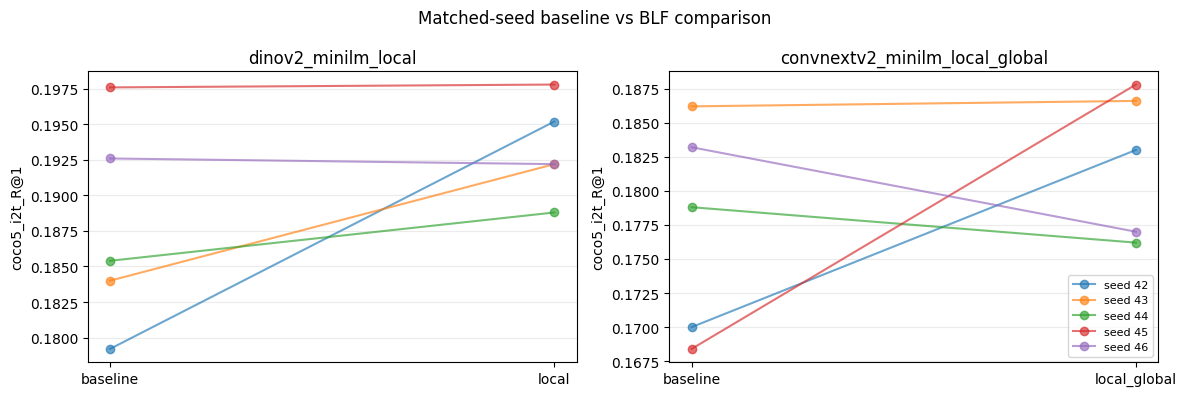

Saved summary tables and results/seed_sweep_matched_comparison.png


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SEED_RESULTS_PATH = PROJECT_ROOT / "results/seed_sweep_results.csv"
SEED_SUMMARY_PATH = PROJECT_ROOT / "results/seed_sweep_summary.csv"
PAIRED_RESULTS_PATH = PROJECT_ROOT / "results/seed_sweep_paired_deltas.csv"
SEED_METRIC = "coco5_i2t_R@1"
T_CRITICAL_95 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262}

if not SEED_RESULTS_PATH.exists():
    display(Markdown(
        f"**Batch results are not available yet.** Expected `{SEED_RESULTS_PATH.relative_to(PROJECT_ROOT)}`. "
        "Submit `scripts/train_seed_sweep_rtxpro.slurm`, then rerun this cell."
    ))
else:
    seed_results = pd.read_csv(SEED_RESULTS_PATH)
    required = {"comparison", "variant", "seed", SEED_METRIC}
    missing = required - set(seed_results.columns)
    if missing:
        raise ValueError(f"Seed result file is missing columns: {sorted(missing)}")
    if seed_results.duplicated(["comparison", "variant", "seed"]).any():
        raise ValueError("Duplicate comparison/variant/seed rows found in the batch results")

    detail_columns = [
        "comparison", "variant", "seed", "best_epoch", "i2t_R@1", "t2i_R@1",
        "coco5_i2t_R@1", "coco5_t2i_R@1", "coco5_i2t_R@5", "coco5_t2i_R@5",
        "best_checkpoint",
    ]
    display(Markdown("### Per-seed results"))
    display(seed_results[[column for column in detail_columns if column in seed_results]].sort_values(["comparison", "seed", "variant"]))

    seed_summary = (
        seed_results.groupby(["comparison", "variant"])[SEED_METRIC]
        .agg(["count", "mean", "std", "min", "max"])
        .reset_index()
        .rename(columns={"count": "n"})
    )
    seed_summary["sem"] = seed_summary["std"] / seed_summary["n"].pow(0.5)
    seed_summary["ci95_half_width"] = [
        T_CRITICAL_95.get(int(n) - 1, 1.96) * sem if int(n) > 1 else float("nan")
        for n, sem in zip(seed_summary["n"], seed_summary["sem"])
    ]

    paired_rows = []
    for comparison, group in seed_results.groupby("comparison"):
        baseline = group[group["variant"] == "baseline"][["seed", SEED_METRIC]].rename(columns={SEED_METRIC: "baseline"})
        for variant in sorted(set(group["variant"]) - {"baseline"}):
            candidate = group[group["variant"] == variant][["seed", SEED_METRIC]].rename(columns={SEED_METRIC: "candidate"})
            paired = baseline.merge(candidate, on="seed", validate="one_to_one")
            paired["delta"] = paired["candidate"] - paired["baseline"]
            n = len(paired)
            delta_std = paired["delta"].std() if n > 1 else float("nan")
            delta_sem = delta_std / n**0.5 if n > 1 else float("nan")
            paired_rows.append({
                "comparison": comparison, "variant": variant, "metric": SEED_METRIC, "n": n,
                "baseline_mean": paired["baseline"].mean(), "candidate_mean": paired["candidate"].mean(),
                "mean_delta": paired["delta"].mean(), "delta_std": delta_std,
                "delta_ci95_half_width": T_CRITICAL_95.get(n - 1, 1.96) * delta_sem if n > 1 else float("nan"),
                "wins": int((paired["delta"] > 0).sum()), "ties": int((paired["delta"] == 0).sum()),
                "losses": int((paired["delta"] < 0).sum()),
            })
    paired_results = pd.DataFrame(paired_rows)
    SEED_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    seed_summary.to_csv(SEED_SUMMARY_PATH, index=False)
    paired_results.to_csv(PAIRED_RESULTS_PATH, index=False)

    display(Markdown("### Aggregate results"))
    display(seed_summary)
    display(Markdown("### Seed-paired BLF minus baseline effects"))
    display(paired_results)

    narrative = ["### Batch conclusion", ""]
    for row in paired_results.itertuples(index=False):
        lower = row.mean_delta - row.delta_ci95_half_width
        upper = row.mean_delta + row.delta_ci95_half_width
        verdict = "positive across the interval" if lower > 0 else ("negative across the interval" if upper < 0 else "uncertain; interval crosses zero")
        narrative.append(
            f"- **{row.comparison} / {row.variant}:** mean Δ={row.mean_delta:+.4f}, "
            f"95% t-interval [{lower:+.4f}, {upper:+.4f}], "
            f"wins/ties/losses={row.wins}/{row.ties}/{row.losses} — {verdict}."
        )
    display(Markdown("\n".join(narrative)))

    comparisons = list(seed_results["comparison"].drop_duplicates())
    fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 4), squeeze=False)
    for axis, comparison in zip(axes[0], comparisons):
        comparison_frame = seed_results[seed_results["comparison"] == comparison]
        pivot = comparison_frame.pivot(index="seed", columns="variant", values=SEED_METRIC)
        variants = ["baseline"] + [column for column in pivot.columns if column != "baseline"]
        for seed, values in pivot[variants].iterrows():
            axis.plot(range(len(variants)), values, marker="o", alpha=0.65, label=f"seed {seed}")
        axis.set_xticks(range(len(variants)), variants)
        axis.set_ylabel(SEED_METRIC)
        axis.set_title(comparison)
        axis.grid(axis="y", alpha=0.25)
    axes[0, -1].legend(loc="best", fontsize=8)
    fig.suptitle("Matched-seed baseline vs BLF comparison")
    fig.tight_layout()
    figure_path = PROJECT_ROOT / "results/seed_sweep_matched_comparison.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved summary tables and {figure_path.relative_to(PROJECT_ROOT)}")


### Step 8A — Qualitative COCO Retrieval for the Two Candidate Models

This subsection compares the two BLF candidate encoder pairs from Step 8 at the same predeclared seed 42: **DINOv2 + MiniLM + local BLF** and **ConvNeXtV2 + MiniLM + local+global BLF**. It uses three captions selected deterministically with seed 42 and ranks each caption against all 5,000 COCO validation images, then displays the ground-truth image and each model's top-five retrieved images side by side.

COCO's public captioned validation split is disjoint from the training images and acts as the held-out gallery here; it is not the official hidden COCO test server. The montage is qualitative and does not establish superiority, particularly because the Step 8 paired confidence intervals cross zero. The two models run sequentially on one GPU and reuse metadata-validated gallery caches on later runs. Checkpoint weights are local, but MiniLM's tokenizer/configuration must already be cached on the node or be fetched once.


Loading qualitative model on cuda:0: DINOv2 + MiniLM + local BLF (seed 42)


/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DINOv2 + MiniLM + local BLF (seed 42): encoding 5000 gallery images in 79 batches
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 1/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 7/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 14/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 21/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 28/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 35/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 42/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 49/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 56/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 63/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 70/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 77/79
DINOv2 + MiniLM + local BLF (seed 42): gallery batch 79/79
Saved qualitative retrieval cache: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/qualitative_retrieval/cache/dinov2_minilm_local_blf_see

,model,checkpoint,gallery_images,qualitative_queries,R@1,R@5,R@10,mean_target_rank
0,DINOv2 + MiniLM + local BLF (seed 42),/mnt/fast/nobackup/scratch4weeks/pp01184/align...,5000,3,0.333333,0.333333,0.666667,122.0
1,ConvNeXtV2 + MiniLM + local+global BLF (seed 42),/mnt/fast/nobackup/scratch4weeks/pp01184/align...,5000,3,0.000000,0.000000,0.333333,182.0


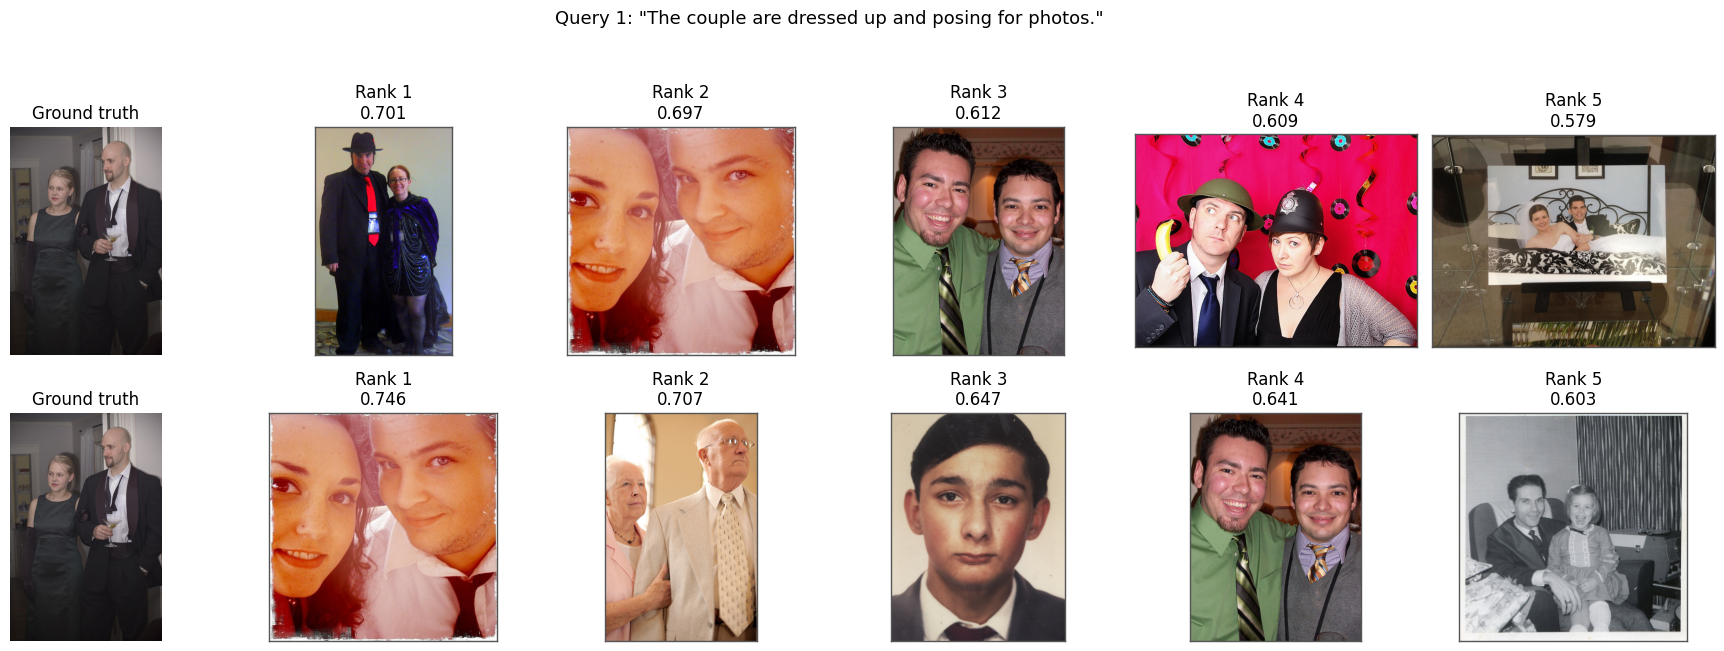

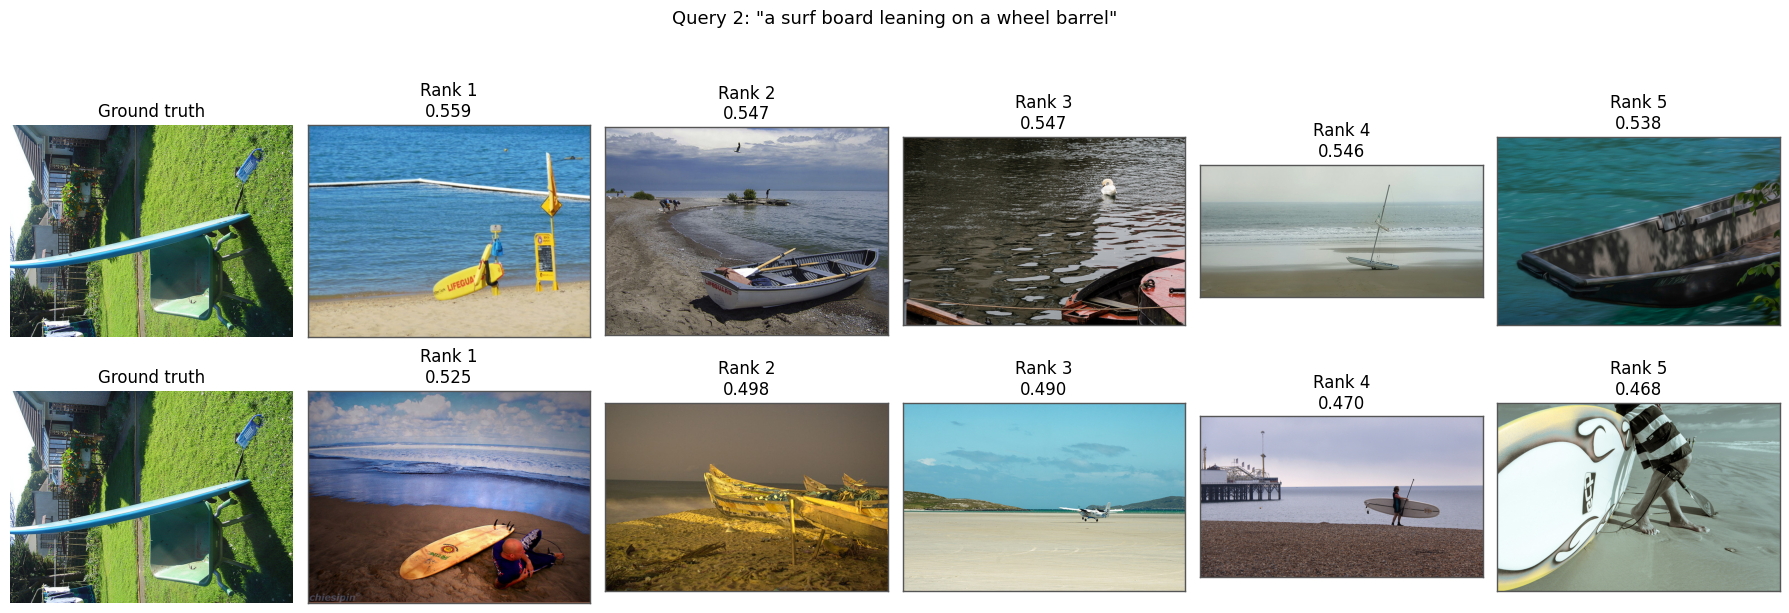

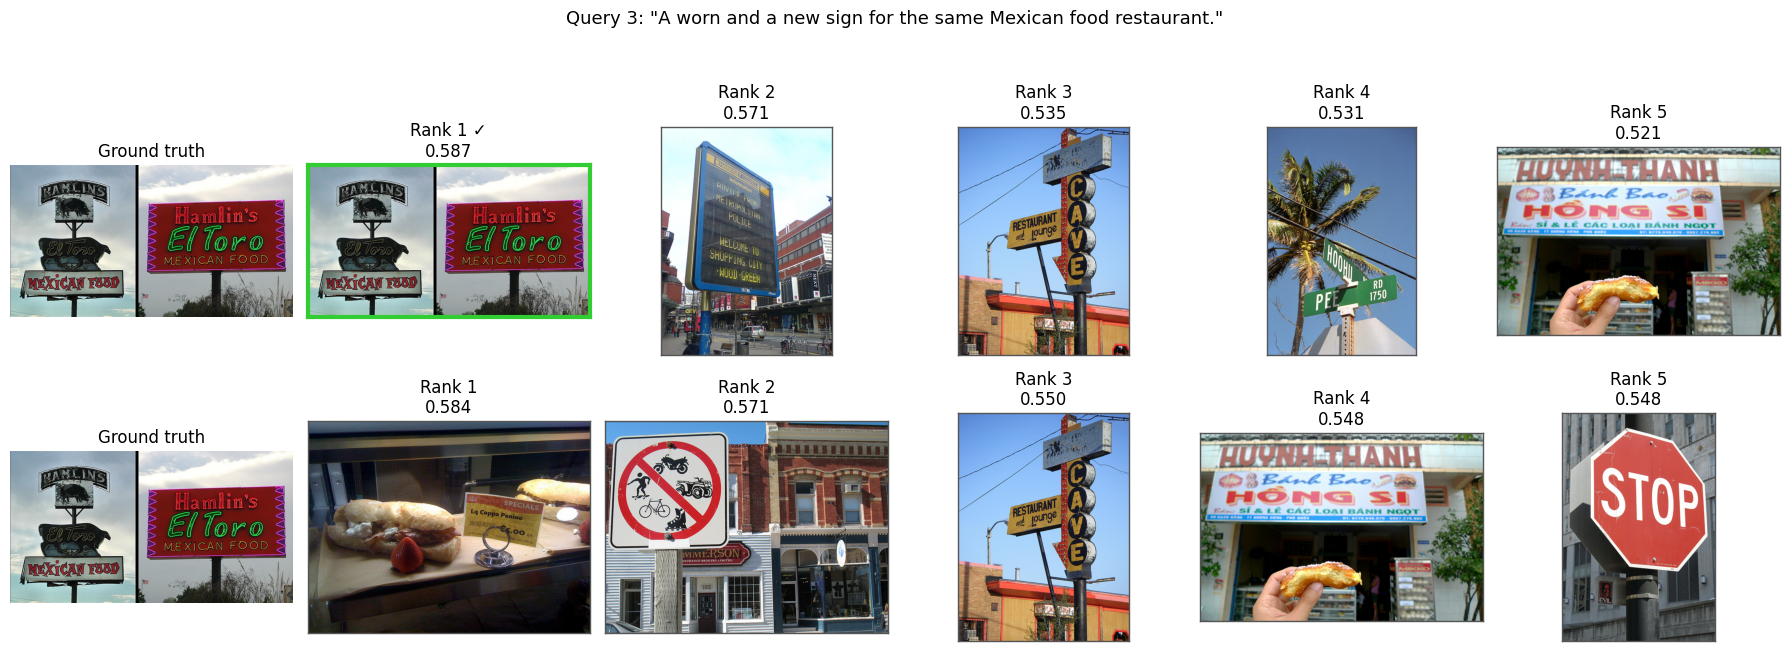

Qualitative outputs: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/qualitative_retrieval
These three deterministic queries are illustrative, not a replacement for the full Step 8 statistics.


In [3]:
from src.multitask.qualitative_retrieval import (
    QualitativeModel,
    display_qualitative_retrieval,
    load_qualitative_retrieval,
    run_qualitative_retrieval,
)

QUALITATIVE_OUTPUT = PROJECT_ROOT / "results/qualitative_retrieval"
QUALITATIVE_MODELS = [
    QualitativeModel(
        label="DINOv2 + MiniLM + local BLF (seed 42)",
        vision_encoder="dinov2_vits14",
        text_encoder="all_minilm_l6_v2",
        variant="local",
        checkpoint="checkpoints/seed_sweep/dinov2_minilm_local_local_seed42/best.pt",
    ),
    QualitativeModel(
        label="ConvNeXtV2 + MiniLM + local+global BLF (seed 42)",
        vision_encoder="convnextv2_tiny",
        text_encoder="all_minilm_l6_v2",
        variant="local_global",
        checkpoint="checkpoints/seed_sweep/convnextv2_minilm_local_global_local_global_seed42/best.pt",
    ),
]

if RUN_QUALITATIVE_RETRIEVAL and not RESULTS_ONLY:
    if not GPU_IDS:
        raise RuntimeError("No visible GPU; qualitative retrieval was not launched")
    qualitative_retrieval = run_qualitative_retrieval(
        PROJECT_ROOT,
        QUALITATIVE_MODELS,
        device="cuda:0",
        num_queries=3,
        topk=5,
        query_seed=42,
        max_images=None,
        output_dir=QUALITATIVE_OUTPUT,
    )
else:
    qualitative_retrieval = load_qualitative_retrieval(QUALITATIVE_OUTPUT)

if qualitative_retrieval is None:
    print("No saved qualitative retrieval exists. Set RUN_QUALITATIVE_RETRIEVAL=True and RESULTS_ONLY=False, then rerun this cell.")
else:
    display(qualitative_retrieval["summary"])
    display_qualitative_retrieval(qualitative_retrieval["rows"], PROJECT_ROOT)
    print("Qualitative outputs:", QUALITATIVE_OUTPUT)
    print("These three deterministic queries are illustrative, not a replacement for the full Step 8 statistics.")


## Step 9 — Validate Retrieval and Zero-Shot Evaluation Datasets

This step validates the selected evaluation scope: COCO retrieval plus CIFAR-100, Oxford-IIIT Pet, and EuroSAT zero-shot classification. It opens the three torchvision datasets with `download=False`, reports exact sample and class counts, and does not contact the web. CIFAR-100 and Pets use their test splits; torchvision exposes EuroSAT as one complete 27,000-image dataset with no official test split.


In [3]:
import pandas as pd
from src.multitask.datasets import validate_datasets

MULTITASK_DATASETS = ["coco_retrieval", "cifar100_zeroshot", "pets_zeroshot", "eurosat_zeroshot"]
dataset_status = pd.DataFrame(validate_datasets(PROJECT_ROOT, MULTITASK_DATASETS))
display(dataset_status)
if not dataset_status.status.eq("ready").all():
    print("Not ready:")
    display(dataset_status.loc[dataset_status.status != "ready"])
else:
    print("All selected datasets are ready; validation used download=False.")


,task,group,status,samples,classes_or_categories,optional,path,detail
0,coco_retrieval,retrieval,ready,25014,NaN,False,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,standard five-caption CSV
1,cifar100_zeroshot,classification,ready,10000,100.0,False,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,torchvision test split; download disabled
2,pets_zeroshot,classification,ready,3669,37.0,False,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,torchvision test split; download disabled
3,eurosat_zeroshot,classification,ready,27000,10.0,False,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,torchvision complete dataset (torchvision prov...


All selected datasets are ready; validation used download=False.


## Step 10 — Retrieval and Zero-Shot Smoke Test

This step runs the focused evaluator tests and, in smoke mode, evaluates one best checkpoint on 8 COCO images and 32 examples from each zero-shot dataset. It verifies offline dataset loading, preprocessing, prompt ensembling, frozen checkpoint loading, task metrics, result writing, and cache reuse before the full run.


In [6]:
if not RESULTS_ONLY:
    subprocess.run([PYTHON, "-m", "pytest", "-q", "tests/multitask", "tests/phase15"], cwd=PROJECT_ROOT, check=True)
from src.multitask.runner import run_multitask_smoke_test
if RUN_MULTITASK_EVALUATION and RUN_MODE == "smoke" and not RESULTS_ONLY:
    smoke = run_multitask_smoke_test(PROJECT_ROOT, MULTITASK_DATASETS, device="cuda" if GPU_IDS else "cpu")
    display(smoke["manifest"]); display(smoke["results"])
else:
    saved = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"
    if saved.exists(): display(pd.read_csv(saved)); print("Loaded saved smoke/full evaluation results:", saved)
    else: print("Results-only: no saved retrieval or zero-shot evaluation exists yet; no model was run.")


..................                                                       [100%]
18 passed in 3.40s
Starting evaluation: convnext_tiny__all_minilm_l6_v2__baseline (/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/checkpoints/convnext_tiny_all_minilm_l6_v2_baseline/best.pt)
Loading frozen model on cuda: convnext_tiny__all_minilm_l6_v2__baseline
Loaded best checkpoint from epoch 2
Encoding 8 unique COCO images in 1 batches
Image encoding: 1/1 batches
Encoding 40 COCO captions in 1 batches
Text encoding: 1/1 batches
Saved embedding cache: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask/cache/convnext_tiny__all_minilm_l6_v2__baseline__coco__smoke.pt
Completed convnext_tiny__all_minilm_l6_v2__baseline/coco_retrieval: coco5_i2t_R@1=1.0000
Evaluating cifar100_zeroshot: 32 images, 100 classes, 1 batches
cifar100_zeroshot: 1/1 batches
Saved zero-shot cache: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask/cache/convnext_tiny__a

,config_id,task,status,checkpoint,cache,predictions,samples,per_class,classes
0,convnext_tiny__all_minilm_l6_v2__baseline,coco_retrieval,complete,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,8,NaN,NaN
1,convnext_tiny__all_minilm_l6_v2__baseline,cifar100_zeroshot,complete,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,32,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,100.0
2,convnext_tiny__all_minilm_l6_v2__baseline,pets_zeroshot,complete,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,32,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,37.0
3,convnext_tiny__all_minilm_l6_v2__baseline,eurosat_zeroshot,complete,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,32,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,10.0


,config_id,vision_encoder,text_encoder,variant,task,metric,value,best_epoch,checkpoint
0,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_i2t_R@1,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
1,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_i2t_R@5,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
2,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_i2t_R@10,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
3,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_mean_rank_i2t,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
4,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_median_rank_i2t,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
5,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_t2i_R@1,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
6,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_t2i_R@5,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
7,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_t2i_R@10,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
8,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_mean_rank_t2i,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
9,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,coco_retrieval,coco5_median_rank_t2i,1.000000,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...


## Step 11 — Full Retrieval and Zero-Shot Evaluation

This step evaluates every selected baseline checkpoint on COCO retrieval and the three zero-shot classification datasets while keeping both pretrained backbones frozen. One independent model configuration runs per GPU; partial runs reuse valid caches, completed configurations are skipped, and every task keeps its own metrics, per-class table, and sample-level predictions. Checkpoint weights are loaded locally; each Hugging Face text encoder still requires its tokenizer and model configuration in the node's cache, or one-time web access if those small files are absent.

| Visible GPUs | Concurrent configurations | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Lowest allocation and simplest diagnosis, but all model pairs run sequentially. |
| 2 | 2 | Roughly doubles configuration throughput with modest shared-filesystem pressure. |
| 4 | 4 | Good balance for the 20 baseline pairs; four datasets are evaluated sequentially inside each worker. |
| 8 | 8 | Highest throughput while at least eight pairs remain, but also the greatest data-loading and cache-write contention. |


In [ ]:
import pandas as pd

MULTITASK_CONFIG_SCOPE = "baseline_all_pairs"
preflight = pd.DataFrame(validate_datasets(PROJECT_ROOT, MULTITASK_DATASETS))
if RUN_MULTITASK_EVALUATION and RUN_MODE == "full" and not RESULTS_ONLY:
    if not GPU_IDS: raise RuntimeError("No visible GPU; multi-task evaluation was not launched")
    if not preflight.status.eq("ready").all():
        display(preflight.loc[preflight.status != "ready"])
        raise RuntimeError("Selected evaluation datasets are not all ready")
    multitask_cmd = [PYTHON, "scripts/run_multitask_jobs.py", "--mode", "full", "--config_scope", MULTITASK_CONFIG_SCOPE, "--datasets", *MULTITASK_DATASETS, "--gpus", *GPU_IDS, "--resume"]
    print("Multi-GPU evaluation command:", " ".join(multitask_cmd))
    try:
        subprocess.run(multitask_cmd, cwd=PROJECT_ROOT, check=True)
    except subprocess.CalledProcessError:
        logs = sorted((PROJECT_ROOT / "logs/multitask").glob("*/*.log"), key=lambda path: path.stat().st_mtime, reverse=True)
        print("Multi-task evaluation failed. Latest worker logs:")
        for log in logs[:len(GPU_IDS)]:
            print(" -", log)
            tail = log.read_text(errors="replace").splitlines()[-20:]
            if tail: print("\n".join(tail))
        raise
    saved = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"
    display(pd.read_csv(saved)); print("Outputs:", saved.parent)
else:
    saved = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"
    if saved.exists(): display(pd.read_csv(saved)); print("Loaded saved multi-task results:", saved)
    else: print("No saved retrieval or zero-shot results yet. Training will not rerun; one evaluation pass is required to create:", saved)


Multi-GPU evaluation command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_multitask_jobs.py --mode full --config_scope baseline_all_pairs --datasets coco_retrieval cifar100_zeroshot pets_zeroshot eurosat_zeroshot --gpus 0 1 2 3 --resume


Skipping completed evaluation: convnext_tiny__bge_small_en__baseline
Skipping completed evaluation: convnext_tiny__distilbert__baseline
Skipping completed evaluation: convnext_tiny__e5_small_v2__baseline
Skipping completed evaluation: convnextv2_tiny__all_minilm_l6_v2__baseline
Skipping completed evaluation: convnextv2_tiny__bge_small_en__baseline
Skipping completed evaluation: convnextv2_tiny__distilbert__baseline
Skipping completed evaluation: convnextv2_tiny__e5_small_v2__baseline
Skipping completed evaluation: dinov2_vits14__all_minilm_l6_v2__baseline
Skipping completed evaluation: dinov2_vits14__bge_small_en__baseline
Skipping completed evaluation: dinov2_vits14__distilbert__baseline
Skipping completed evaluation: dinov2_vits14__e5_small_v2__baseline
Skipping completed evaluation: efficientnet_b0__all_minilm_l6_v2__baseline
Running 8 configuration jobs across 4 GPUs: 0, 1, 2, 3
[GPU 0] started 1/8: convnext_tiny__all_minilm_l6_v2__baseline; log=/mnt/fast/nobackup/scratch4weeks/pp0

## Step 11.5 — Experimenting BLF with Best Retrieval Performers Plus Intuitive 3rd Best

This targeted extension evaluates three existing BLF checkpoints on the same COCO retrieval and zero-shot classification tasks as Step 11; it does **not** train or overwrite a model. The confirmatory candidates are **DINOv2 + MiniLM + local BLF** and **ConvNeXtV2 + MiniLM + local+global BLF**, selected from the matched-seed retrieval study. The exploratory third candidate is **DINOv2 + BGE + local BLF**, combining the strongest baseline multi-task components with a positive single-run BLF retrieval delta. Results are appended to Step 11's canonical tables under distinct variant-aware configuration IDs. Resume mode skips each completed BLF configuration and leaves all completed baselines untouched.

| Visible GPUs | Concurrent BLF configurations | Expected trade-off |
|---:|---:|---|
| 1 | 1 | Lowest allocation, but the three targeted evaluations run sequentially. |
| 2 | 2 | Two candidates run together, followed by the remaining candidate. |
| 4 | 3 | All three candidates can run concurrently; the fourth GPU remains idle. |
| 8 | 3 | No speed-up over three or four GPUs because this step contains only three independent jobs. |


In [4]:
BLF_MULTITASK_CONFIG_IDS = [
    "dinov2_vits14__all_minilm_l6_v2__local",
    "convnextv2_tiny__all_minilm_l6_v2__local_global",
    "dinov2_vits14__bge_small_en__local",
]
blf_preflight = pd.DataFrame(validate_datasets(PROJECT_ROOT, MULTITASK_DATASETS))
saved = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"
if RUN_MULTITASK_EVALUATION and RUN_MODE == "full" and not RESULTS_ONLY:
    if not GPU_IDS: raise RuntimeError("No visible GPU; targeted BLF evaluation was not launched")
    if not blf_preflight.status.eq("ready").all():
        display(blf_preflight.loc[blf_preflight.status != "ready"])
        raise RuntimeError("Selected evaluation datasets are not all ready")
    blf_cmd = [PYTHON, "scripts/run_multitask_jobs.py", "--mode", "full", "--config_scope", "baseline_plus_reliable_blf", "--config_ids", *BLF_MULTITASK_CONFIG_IDS, "--datasets", *MULTITASK_DATASETS, "--gpus", *GPU_IDS, "--resume"]
    print("Targeted multi-GPU BLF evaluation command:", " ".join(blf_cmd))
    try:
        subprocess.run(blf_cmd, cwd=PROJECT_ROOT, check=True)
    except subprocess.CalledProcessError:
        logs = sorted((PROJECT_ROOT / "logs/multitask").glob("*/*.log"), key=lambda path: path.stat().st_mtime, reverse=True)
        print("Targeted BLF evaluation failed. Latest worker logs:")
        for log in logs[:min(len(GPU_IDS), len(BLF_MULTITASK_CONFIG_IDS))]:
            print(" -", log)
            tail = log.read_text(errors="replace").splitlines()[-20:]
            if tail: print("\n".join(tail))
        raise
if saved.exists():
    blf_results = pd.read_csv(saved)
    blf_results = blf_results[blf_results.config_id.isin(BLF_MULTITASK_CONFIG_IDS)].copy()
    if blf_results.empty:
        print("No saved Step 11.5 BLF results yet. Enable the evaluation switches to run the three existing checkpoints.")
    else:
        display(blf_results.sort_values(["config_id", "task", "metric"]))
        completed = sorted(blf_results.config_id.unique())
        print(f"Loaded {len(completed)}/{len(BLF_MULTITASK_CONFIG_IDS)} targeted BLF configurations:", completed)
else:
    print("Step 11 results table is missing:", saved)


Targeted multi-GPU BLF evaluation command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_multitask_jobs.py --mode full --config_scope baseline_plus_reliable_blf --config_ids dinov2_vits14__all_minilm_l6_v2__local convnextv2_tiny__all_minilm_l6_v2__local_global dinov2_vits14__bge_small_en__local --datasets coco_retrieval cifar100_zeroshot pets_zeroshot eurosat_zeroshot --gpus 0 1 2 3 --resume
Running 3 configuration jobs across 4 GPUs: 0, 1, 2, 3
[GPU 0] started 1/3: convnextv2_tiny__all_minilm_l6_v2__local_global; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784038976_1777437/job_001_convnextv2_tiny__all_minilm_l6_v2__local_global.log
[GPU 1] started 2/3: dinov2_vits14__all_minilm_l6_v2__local; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784038976_1777437/job_002_dinov2_vits14__all_minilm_l6_v2__local.log
[GPU 2] started 3/3: dinov2_vits14__bge_small_en__local; log=/mnt/fast/nobackup/scra

,config_id,vision_encoder,text_encoder,variant,task,metric,value,best_epoch,checkpoint,mode
708,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,balanced_accuracy,0.290100,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
710,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,classification_margin,-0.027152,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
707,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,macro_f1,0.250478,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
709,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,mean_confidence,0.394817,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
705,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,top1_accuracy,0.290100,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
...,...,...,...,...,...,...,...,...,...,...
747,dinov2_vits14__bge_small_en__local,dinov2_vits14,bge_small_en,local,pets_zeroshot,macro_f1,0.037741,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
749,dinov2_vits14__bge_small_en__local,dinov2_vits14,bge_small_en,local,pets_zeroshot,mean_confidence,0.227383,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
745,dinov2_vits14__bge_small_en__local,dinov2_vits14,bge_small_en,local,pets_zeroshot,top1_accuracy,0.058599,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
751,dinov2_vits14__bge_small_en__local,dinov2_vits14,bge_small_en,local,pets_zeroshot,top1_margin,0.079989,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full


Loaded 3/3 targeted BLF configurations: ['convnextv2_tiny__all_minilm_l6_v2__local_global', 'dinov2_vits14__all_minilm_l6_v2__local', 'dinov2_vits14__bge_small_en__local']


## Step 12 — Retrieval and Zero-Shot Findings

This step reads the saved outputs without training or evaluating a model. It displays the best configuration for each task's headline metric and the complete task-specific results. Retrieval recall and classification accuracy are not averaged together because they measure different outcomes.


In [7]:
import importlib
import pandas as pd
import src.multitask.reporting as multitask_reporting

# Reload because this notebook kernel may have cached the previous reporting.py.
multitask_reporting = importlib.reload(multitask_reporting)

results_long = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"

if results_long.exists():
    task_results = pd.read_csv(results_long)

    if "mode" in task_results.columns:
        full_results = task_results[task_results["mode"] == "full"].copy()
    else:
        full_results = task_results.copy()

    # Best configuration across all Step 11 and Step 11.5 models.
    headline_metrics = [
        "coco5_i2t_R@1",
        "coco5_t2i_R@1",
        "top1_accuracy",
    ]
    headline = full_results[
        full_results["metric"].isin(headline_metrics)
    ].copy()

    best = headline.loc[
        headline.groupby(["task", "metric"])["value"].idxmax()
    ]

    print("Best configuration per task and headline metric:")
    display(
        best.sort_values(["task", "metric"])[
            [
                "task",
                "metric",
                "config_id",
                "vision_encoder",
                "text_encoder",
                "variant",
                "value",
            ]
        ]
    )

    # Exact matched BLF-versus-baseline comparison.
    matched = multitask_reporting.build_matched_blf_comparison(
        full_results,
        require_complete=True,
    )

    matched_summary = (
        multitask_reporting.summarize_matched_blf_comparison(matched)
    )

    comparison_table = matched[
        [
            "comparison",
            "metric_label",
            "baseline_value",
            "blf_value",
            "delta_percentage_points",
            "outcome",
        ]
    ].copy()

    comparison_table["baseline_value"] *= 100
    comparison_table["blf_value"] *= 100
    comparison_table["outcome"] = (
        comparison_table["outcome"].str.replace("_", " ").str.title()
    )

    comparison_table = comparison_table.rename(
        columns={
            "metric_label": "metric",
            "baseline_value": "baseline (%)",
            "blf_value": "BLF (%)",
            "delta_percentage_points": "BLF change (pp)",
            "outcome": "outcome",
        }
    )

    print("Matched BLF-versus-baseline results:")
    display(comparison_table.round(3))

    print("BLF wins, ties, and losses:")
    display(
        matched_summary[
            [
                "comparison",
                "metrics_compared",
                "wins",
                "ties",
                "losses",
            ]
        ]
    )

    # Refresh persistent Markdown, JSON, and comparison CSV outputs.
    if not RESULTS_ONLY:
        summary_paths = multitask_reporting.write_multitask_summary(
            results_long.parent
        )
        print("Updated summaries:", summary_paths)
        print(
            "Detailed comparison:",
            results_long.parent / "blf_vs_baseline_multitask.csv",
        )
    else:
        print(
            "Results-only mode: comparison displayed, but saved summaries "
            "were not refreshed."
        )

    display(
        full_results.sort_values(
            ["task", "metric", "value"],
            ascending=[True, True, False],
        )
    )
else:
    print("Step 11 output missing:", results_long)

Best configuration per task and headline metric:


,task,metric,config_id,vision_encoder,text_encoder,variant,value
111,cifar100_zeroshot,top1_accuracy,convnextv2_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny,all_minilm_l6_v2,baseline,0.295100
660,coco_retrieval,coco5_i2t_R@1,dinov2_vits14__all_minilm_l6_v2__local,dinov2_vits14,all_minilm_l6_v2,local,0.195200
665,coco_retrieval,coco5_t2i_R@1,dinov2_vits14__all_minilm_l6_v2__local,dinov2_vits14,all_minilm_l6_v2,local,0.160470
290,eurosat_zeroshot,top1_accuracy,dinov2_vits14__bge_small_en__baseline,dinov2_vits14,bge_small_en,baseline,0.222889
283,pets_zeroshot,top1_accuracy,dinov2_vits14__bge_small_en__baseline,dinov2_vits14,bge_small_en,baseline,0.068684


Matched BLF-versus-baseline results:


,comparison,metric,baseline (%),BLF (%),BLF change (pp),outcome
0,dinov2_minilm_local,COCO i2t R@1,17.920,19.520,1.600,Blf Win
1,dinov2_minilm_local,COCO t2i R@1,15.435,16.047,0.612,Blf Win
2,dinov2_minilm_local,CIFAR-100 top-1 accuracy,25.490,26.040,0.550,Blf Win
3,dinov2_minilm_local,Pets top-1 accuracy,6.214,5.642,-0.572,Blf Loss
4,dinov2_minilm_local,EuroSAT top-1 accuracy,20.007,19.452,-0.556,Blf Loss
5,convnextv2_minilm_local_global,COCO i2t R@1,17.000,18.300,1.300,Blf Win
6,convnextv2_minilm_local_global,COCO t2i R@1,15.024,15.479,0.456,Blf Win
7,convnextv2_minilm_local_global,CIFAR-100 top-1 accuracy,29.510,29.010,-0.500,Blf Loss
8,convnextv2_minilm_local_global,Pets top-1 accuracy,4.443,3.788,-0.654,Blf Loss
9,convnextv2_minilm_local_global,EuroSAT top-1 accuracy,21.789,19.219,-2.570,Blf Loss


BLF wins, ties, and losses:


,comparison,metrics_compared,wins,ties,losses
0,dinov2_minilm_local,5,3,0,2
1,convnextv2_minilm_local_global,5,2,0,3
2,dinov2_bge_local_exploratory,5,2,0,3


Updated summaries: (PosixPath('/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask/multitask_summary.md'), PosixPath('/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask/multitask_summary.json'))
Detailed comparison: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask/blf_vs_baseline_multitask.csv


,config_id,vision_encoder,text_encoder,variant,task,metric,value,best_epoch,checkpoint,mode
114,convnextv2_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny,all_minilm_l6_v2,baseline,cifar100_zeroshot,balanced_accuracy,0.295100,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
708,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,cifar100_zeroshot,balanced_accuracy,0.290100,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
213,convnextv2_tiny__e5_small_v2__baseline,convnextv2_tiny,e5_small_v2,baseline,cifar100_zeroshot,balanced_accuracy,0.286700,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
147,convnextv2_tiny__bge_small_en__baseline,convnextv2_tiny,bge_small_en,baseline,cifar100_zeroshot,balanced_accuracy,0.281700,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
15,convnext_tiny__bge_small_en__baseline,convnext_tiny,bge_small_en,baseline,cifar100_zeroshot,balanced_accuracy,0.267100,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
...,...,...,...,...,...,...,...,...,...,...
119,convnextv2_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny,all_minilm_l6_v2,baseline,pets_zeroshot,top5_accuracy,0.189970,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
581,swin_tiny__distilbert__baseline,swin_tiny,distilbert,baseline,pets_zeroshot,top5_accuracy,0.186427,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
317,dinov2_vits14__distilbert__baseline,dinov2_vits14,distilbert,baseline,pets_zeroshot,top5_accuracy,0.180158,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full
416,efficientnet_b0__distilbert__baseline,efficientnet_b0,distilbert,baseline,pets_zeroshot,top5_accuracy,0.157536,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,full


## Step 13 — Phase 1.5: Build, Audit, and Validate Development Predictions

This step can explicitly evaluate the frozen checkpoints on the leakage-safe classification development partitions using the multi-GPU coordinator, while reusing COCO val2017 as the declared retrieval-development evidence. It then inventories Phase 1/1.5 artifacts and strictly validates every configuration–task–direction export against its cache, checkpoint fingerprint, split metadata, sample IDs, class count, finite scores, and recall/margin consistency. Full mode materialises missing COCO text-to-image rows from saved embeddings; it never retrains a model. The development evaluation is separately gated and disabled by default. Results-only mode displays saved audit and coverage tables.


In [4]:
import pandas as pd
from src.phase15.audit import run_phase15_audit
from src.phase15.development_evidence import assemble_development_evidence
from src.phase15.prediction_validation import run_prediction_validation

audit_root = PROJECT_ROOT / "results/phase15/audit"
coverage_root = PROJECT_ROOT / "results/phase15/prediction_validation"
development_root = PROJECT_ROOT / "results/phase1_multitask_development"
if RUN_PHASE15 and RUN_DEVELOPMENT_EVALUATION and not RESULTS_ONLY:
    if RUN_MODE != "full": raise ValueError("The frozen Phase 2 selection evidence requires RUN_MODE='full'.")
    if not GPU_IDS: raise RuntimeError("Development evaluation requires an allocated GPU.")
    historical_results = pd.read_csv(PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv")
    if "mode" in historical_results: historical_results = historical_results[historical_results["mode"].eq("full")]
    development_config_ids = sorted(historical_results["config_id"].dropna().unique())
    development_cmd = [
        PYTHON, "scripts/run_multitask_jobs.py",
        "--mode", "full",
        "--split_role", "development",
        "--config_scope", "baseline_plus_reliable_blf",
        "--config_ids", *development_config_ids,
        "--datasets", "cifar100_zeroshot", "pets_zeroshot", "eurosat_zeroshot",
        "--gpus", *GPU_IDS,
        "--resume",
    ]
    print("Leakage-safe multi-GPU development command:", " ".join(development_cmd))
    subprocess.run(development_cmd, cwd=PROJECT_ROOT, check=True)
    display(assemble_development_evidence(PROJECT_ROOT, strict=True))
elif RUN_DEVELOPMENT_EVALUATION:
    print("Development evaluation not launched because RUN_PHASE15 is false or RESULTS_ONLY is true.")
elif (development_root / "development_evidence_manifest.json").exists():
    print("Reusing assembled development evidence:", development_root)
else:
    print("Historical classification outputs remain exploratory. Enable RUN_DEVELOPMENT_EVALUATION only for the final allocated full run.")
if RUN_PHASE15 and not RESULTS_ONLY:
    artifact_audit = run_phase15_audit(PROJECT_ROOT)
    display(artifact_audit)
    prediction_coverage = run_prediction_validation(
        PROJECT_ROOT,
        mode=RUN_MODE,
        strict=(RUN_MODE == "full"),
        materialize_missing_retrieval=(RUN_MODE == "full"),
        device="cuda:0" if torch.cuda.is_available() else "cpu",
    )
    display(prediction_coverage)
else:
    print("Saved notebook output may be stale after the Phase 1.5 repair; rerun this cell to refresh it.")
    for result_path in (audit_root / "phase15_artifact_audit.csv", coverage_root / "coverage_report.csv", coverage_root / "missing_predictions.csv"):
        if result_path.exists():
            print("Saved output:", result_path)
            display(pd.read_csv(result_path))
        else:
            print("Not yet generated:", result_path)


Leakage-safe multi-GPU development command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_multitask_jobs.py --mode full --split_role development --config_scope baseline_plus_reliable_blf --config_ids convnext_tiny__all_minilm_l6_v2__baseline convnext_tiny__bge_small_en__baseline convnext_tiny__distilbert__baseline convnext_tiny__e5_small_v2__baseline convnextv2_tiny__all_minilm_l6_v2__baseline convnextv2_tiny__all_minilm_l6_v2__local_global convnextv2_tiny__bge_small_en__baseline convnextv2_tiny__distilbert__baseline convnextv2_tiny__e5_small_v2__baseline dinov2_vits14__all_minilm_l6_v2__baseline dinov2_vits14__all_minilm_l6_v2__local dinov2_vits14__bge_small_en__baseline dinov2_vits14__bge_small_en__local dinov2_vits14__distilbert__baseline dinov2_vits14__e5_small_v2__baseline efficientnet_b0__all_minilm_l6_v2__baseline efficientnet_b0__bge_small_en__baseline efficientnet_b0__distilbert__baseline efficientnet_b0__e5_small_v2__baseline swin_tiny__a

Running 23 configuration jobs across 4 GPUs: 0, 1, 2, 3
[GPU 0] started 1/23: convnext_tiny__all_minilm_l6_v2__baseline; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784055300_2002964/job_001_convnext_tiny__all_minilm_l6_v2__baseline.log
[GPU 1] started 2/23: convnext_tiny__bge_small_en__baseline; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784055300_2002964/job_002_convnext_tiny__bge_small_en__baseline.log
[GPU 2] started 3/23: convnext_tiny__distilbert__baseline; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784055300_2002964/job_003_convnext_tiny__distilbert__baseline.log
[GPU 3] started 4/23: convnext_tiny__e5_small_v2__baseline; log=/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/multitask/1784055300_2002964/job_004_convnext_tiny__e5_small_v2__baseline.log
[GPU 0 | convnext_tiny__all_minilm_l6_v2__baseline] Worker starting configuration convnext_tiny__all_minilm_l6_v2__baseline on

{'status': 'complete',
 'configurations': 23,
 'tasks': ['cifar100_zeroshot',
  'coco_retrieval',
  'eurosat_zeroshot',
  'pets_zeroshot'],
 'coco_source': 'historical COCO val2017 reused as frozen development evidence',
 'classification_source': 'deterministic train/trainval/EuroSAT development partitions',
 'historical_classification_test_rows_reused': False,
 'paths': {'results_long': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_development/task_results_long.csv',
  'status': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_development/task_status.csv',
  'manifest': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_development/evaluation_manifest.csv',
  'results_wide': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_development/task_results_wide.csv',
  'summary': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_develop

,artifact,exists,valid,row_count,configuration_count,task_count,checkpoint_fingerprint_status,schema_status,issues
0,results/alignment_matrix_best_clean.csv,True,True,80,80,0,not_applicable,valid,
1,results/seed_sweep_results.csv,True,True,20,4,0,not_applicable,valid,
2,results/seed_sweep_summary.csv,True,True,4,0,0,not_applicable,valid,
3,results/seed_sweep_paired_deltas.csv,True,True,2,0,0,not_applicable,valid,
4,results/phase1_multitask,True,True,92,23,4,matched,valid,
5,results/phase15/predictions,True,True,24,0,0,not_applicable,historical_mixed,
6,results/phase15/complementarity,True,True,759,23,3,not_applicable,valid,
7,results/phase15/oracle,True,True,6075,0,3,not_applicable,valid,
8,results/phase15/cross_task,True,True,115,23,0,not_applicable,valid,
9,results/phase15/efficiency,True,True,23,23,0,not_applicable,valid,


,configuration_id,task,direction,mode,dataset_split,source_path,exists,readable,valid,expected_samples,...,nonfinite_score_count,invalid_prediction_count,class_count,expected_class_count,checkpoint_fingerprint_status,checkpoint_stat_fingerprint,schema_status,cache_metadata_status,issues,missing_columns
0,convnext_tiny__all_minilm_l6_v2__baseline,cifar100_zeroshot,classification,full,cifar100_official_train_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,10000,...,0,0,100.0,100.0,matched_legacy_stat,3611124968eafef24000,valid,valid,,[]
1,convnext_tiny__all_minilm_l6_v2__baseline,coco_retrieval,i2t,full,coco_val2017_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,5000,...,0,0,NaN,NaN,matched_legacy_stat,3611124968eafef24000,valid,valid,,[]
2,convnext_tiny__all_minilm_l6_v2__baseline,coco_retrieval,t2i,full,coco_val2017_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,25014,...,0,0,NaN,NaN,matched_legacy_stat,3611124968eafef24000,valid,valid,,[]
3,convnext_tiny__all_minilm_l6_v2__baseline,eurosat_zeroshot,classification,full,eurosat_deterministic_stratified_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,4050,...,0,0,10.0,10.0,matched_legacy_stat,3611124968eafef24000,valid,valid,,[]
4,convnext_tiny__all_minilm_l6_v2__baseline,pets_zeroshot,classification,full,oxford_iiit_pet_trainval_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,736,...,0,0,37.0,37.0,matched_legacy_stat,3611124968eafef24000,valid,valid,,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,swin_tiny__e5_small_v2__baseline,cifar100_zeroshot,classification,full,cifar100_official_train_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,10000,...,0,0,100.0,100.0,matched_legacy_stat,ad8a64619ef2b4796cba,valid,valid,,[]
111,swin_tiny__e5_small_v2__baseline,coco_retrieval,i2t,full,coco_val2017_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,5000,...,0,0,NaN,NaN,matched_legacy_stat,ad8a64619ef2b4796cba,valid,valid,,[]
112,swin_tiny__e5_small_v2__baseline,coco_retrieval,t2i,full,coco_val2017_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,25014,...,0,0,NaN,NaN,matched_legacy_stat,ad8a64619ef2b4796cba,valid,valid,,[]
113,swin_tiny__e5_small_v2__baseline,eurosat_zeroshot,classification,full,eurosat_deterministic_stratified_development,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,True,True,True,4050,...,0,0,10.0,10.0,matched_legacy_stat,ad8a64619ef2b4796cba,valid,valid,,[]


## Step 14 — Phase 1.5: Complementarity, Oracle, and Cross-Task Analysis

This step measures retrieval and dataset-specific classification complementarity, per-class unique wins, pair/triple/full-pool classification oracle bounds, cross-task ranks and correlations, expert specialisation, and performance–latency trade-offs. Raw heterogeneous metrics are retained but never averaged without within-task normalisation. Oracle results are diagnostic upper bounds—not trained or deployable ensembles. Optional compositional tasks are reported separately and never block retrieval-plus-classification analysis.


{'anchor_text': 'all_minilm_l6_v2',
 'anchor_vision': 'dinov2_vits14',
 'mode': 'full',
 'evaluation_root': '/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase1_multitask_development',
 'strict_validation': True,
 'prediction_files': 23,
 'coverage_exports': 115,
 'coverage_valid_exports': 115,
 'config_ids': ['convnext_tiny__all_minilm_l6_v2__baseline',
  'convnext_tiny__bge_small_en__baseline',
  'convnext_tiny__distilbert__baseline',
  'convnext_tiny__e5_small_v2__baseline',
  'convnextv2_tiny__all_minilm_l6_v2__baseline',
  'convnextv2_tiny__all_minilm_l6_v2__local_global',
  'convnextv2_tiny__bge_small_en__baseline',
  'convnextv2_tiny__distilbert__baseline',
  'convnextv2_tiny__e5_small_v2__baseline',
  'dinov2_vits14__all_minilm_l6_v2__baseline',
  'dinov2_vits14__all_minilm_l6_v2__local',
  'dinov2_vits14__bge_small_en__baseline',
  'dinov2_vits14__bge_small_en__local',
  'dinov2_vits14__distilbert__baseline',
  'dinov2_vits14__e5_small_v2__baseline',
  'effic

complementarity/retrieval_pairwise.csv (253 rows)


,expert_a,expert_b,both_successful,only_a_successful,only_b_successful,both_unsuccessful,jaccard,oracle_recall
0,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__bge_small_en__baseline,424,502,465,3609,0.304817,0.2782
1,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__distilbert__baseline,269,657,330,3744,0.214172,0.2512
2,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__e5_small_v2__baseline,371,555,459,3615,0.267870,0.2770
3,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__all_minilm_l6_v2__baseline,400,526,450,3624,0.290698,0.2752
4,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__all_minilm_l6_v2__local_global,381,545,534,3540,0.260959,0.2920
5,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__bge_small_en__baseline,339,587,514,3560,0.235417,0.2880
6,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__distilbert__baseline,235,691,330,3744,0.187102,0.2512
7,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__e5_small_v2__baseline,292,634,493,3581,0.205779,0.2838
8,convnext_tiny__all_minilm_l6_v2__baseline,dinov2_vits14__all_minilm_l6_v2__baseline,332,594,564,3510,0.222819,0.2980
9,convnext_tiny__all_minilm_l6_v2__baseline,dinov2_vits14__all_minilm_l6_v2__local,343,583,633,3441,0.220013,0.3118


complementarity/classification_pairwise.csv (759 rows)


,dataset,configuration_a,configuration_b,sample_count,agreement_count,agreement_rate,disagreement_count,disagreement_rate,both_correct,only_a_correct,...,only_b_fraction,both_incorrect_fraction,correct_set_jaccard,prediction_label_agreement,confidence_pearson,confidence_spearman,margin_pearson,margin_spearman,unique_correct_a,unique_correct_b
0,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__bge_small_en__baseline,10000,4013,0.4013,5987,0.5987,2039,604,...,0.0655,0.6702,0.618253,0.4013,0.765725,0.667769,0.815487,0.655518,604,655
1,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__distilbert__baseline,10000,3209,0.3209,6791,0.6791,1731,912,...,0.0614,0.6743,0.531471,0.3209,0.615912,0.543357,0.668677,0.536046,912,614
2,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny__e5_small_v2__baseline,10000,3798,0.3798,6202,0.6202,1968,675,...,0.0690,0.6667,0.590459,0.3798,0.735622,0.637865,0.777845,0.613136,675,690
3,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__all_minilm_l6_v2__baseline,10000,3377,0.3377,6623,0.6623,2009,634,...,0.0970,0.6387,0.556048,0.3377,0.625644,0.522286,0.691519,0.525850,634,970
4,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__all_minilm_l6_v2__local_global,10000,3284,0.3284,6716,0.6716,2024,619,...,0.0906,0.6451,0.570301,0.3284,0.616331,0.519508,0.693726,0.524631,619,906
5,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__bge_small_en__baseline,10000,2835,0.2835,7165,0.7165,1841,802,...,0.1008,0.6349,0.504245,0.2835,0.591764,0.497850,0.641178,0.457657,802,1008
6,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__distilbert__baseline,10000,2441,0.2441,7559,0.7559,1625,1018,...,0.0861,0.6496,0.463756,0.2441,0.544348,0.471456,0.560455,0.395047,1018,861
7,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny__e5_small_v2__baseline,10000,2860,0.2860,7140,0.7140,1825,818,...,0.1026,0.6331,0.497411,0.2860,0.617073,0.507502,0.653565,0.454725,818,1026
8,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,dinov2_vits14__all_minilm_l6_v2__baseline,10000,2645,0.2645,7355,0.7355,1688,955,...,0.0922,0.6435,0.473492,0.2645,0.541767,0.451111,0.593518,0.418953,955,922
9,cifar100_zeroshot,convnext_tiny__all_minilm_l6_v2__baseline,dinov2_vits14__all_minilm_l6_v2__local,10000,2785,0.2785,7215,0.7215,1750,893,...,0.0896,0.6461,0.494490,0.2785,0.525118,0.447477,0.594289,0.436627,893,896


...

,config_id,vision_encoder,text_encoder,variant,tasks_evaluated,tasks_won,tasks_within_threshold,mean_normalised_multitask_score,std_normalised_task_performance,task_specialisation_index,...,cost_adjusted_task_score,strongest_task,strongest_task_score,strongest_task_relative_gap,weakest_task,weakest_task_score,weakest_task_relative_gap,task_specific_strengths,task_specific_weaknesses,normalisation
0,dinov2_vits14__bge_small_en__baseline,dinov2_vits14,bge_small_en,baseline,5,1,1,0.932664,0.040893,0.040893,...,0.629903,eurosat,0.222716,0.000000,coco_i2t,0.173600,0.110656,"[""eurosat"", ""pets""]","[""cifar100"", ""coco_i2t""]",relative_to_task_best
1,dinov2_vits14__all_minilm_l6_v2__baseline,dinov2_vits14,all_minilm_l6_v2,baseline,5,0,0,0.917195,0.040748,0.040748,...,0.652210,pets,0.070652,0.037037,eurosat,0.193086,0.133038,"[""pets"", ""coco_t2i""]","[""cifar100"", ""eurosat""]",relative_to_task_best
2,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,5,0,1,0.900918,0.076553,0.076553,...,0.671582,cifar100,0.293000,0.016448,pets,0.058424,0.203704,"[""cifar100"", ""coco_t2i""]","[""eurosat"", ""pets""]",relative_to_task_best
3,convnextv2_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny,all_minilm_l6_v2,baseline,5,1,1,0.895514,0.104924,0.104924,...,0.697295,cifar100,0.297900,0.000000,pets,0.051630,0.296296,"[""cifar100"", ""eurosat""]","[""coco_i2t"", ""pets""]",relative_to_task_best
4,dinov2_vits14__e5_small_v2__baseline,dinov2_vits14,e5_small_v2,baseline,5,1,1,0.887248,0.060854,0.060854,...,0.587189,pets,0.073370,0.000000,coco_i2t,0.162200,0.169057,"[""pets"", ""eurosat""]","[""coco_t2i"", ""coco_i2t""]",relative_to_task_best
5,dinov2_vits14__bge_small_en__local,dinov2_vits14,bge_small_en,local,5,0,0,0.883513,0.103669,0.103669,...,0.589775,coco_t2i,0.154114,0.039611,pets,0.050272,0.314815,"[""coco_t2i"", ""eurosat""]","[""cifar100"", ""pets""]",relative_to_task_best
6,dinov2_vits14__all_minilm_l6_v2__local,dinov2_vits14,all_minilm_l6_v2,local,5,2,2,0.869177,0.156132,0.156132,...,0.607477,coco_i2t,0.195200,0.000000,pets,0.042120,0.425926,"[""coco_i2t"", ""coco_t2i""]","[""eurosat"", ""pets""]",relative_to_task_best
7,convnextv2_tiny__bge_small_en__baseline,convnextv2_tiny,bge_small_en,baseline,5,0,0,0.865169,0.067790,0.067790,...,0.629998,cifar100,0.284900,0.043639,eurosat,0.168395,0.243902,"[""cifar100"", ""coco_t2i""]","[""pets"", ""eurosat""]",relative_to_task_best
8,convnext_tiny__bge_small_en__baseline,convnext_tiny,bge_small_en,baseline,5,0,0,0.864290,0.090226,0.090226,...,0.656055,coco_t2i,0.148837,0.072496,pets,0.050272,0.314815,"[""coco_t2i"", ""coco_i2t""]","[""eurosat"", ""pets""]",relative_to_task_best
9,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,5,0,1,0.853976,0.115251,0.115251,...,0.706688,coco_t2i,0.157632,0.017688,pets,0.048913,0.333333,"[""coco_t2i"", ""coco_i2t""]","[""eurosat"", ""pets""]",relative_to_task_best


cross_task/task_rank_correlations.csv (10 rows)


,task_a,task_b,configuration_count,spearman,kendall
0,coco_i2t,coco_t2i,23,0.988142,0.944664
1,coco_i2t,cifar100,23,0.779644,0.581028
2,coco_i2t,pets,23,0.449394,0.316023
3,coco_i2t,eurosat,23,0.472332,0.312253
4,coco_t2i,cifar100,23,0.796443,0.604743
5,coco_t2i,pets,23,0.437021,0.308022
6,coco_t2i,eurosat,23,0.467391,0.304348
7,cifar100,pets,23,0.283099,0.196014
8,cifar100,eurosat,23,0.495059,0.351779
9,pets,eurosat,23,0.227667,0.148011


compositional/task_status.csv (2 rows)


,task,status,dataset_path,prediction_files,allowed_for_training,usage,issues
0,winoground,missing,NaN,0,False,evaluation_only,dataset is not installed; no automatic downloa...
1,sugarcrepe,missing,NaN,0,False,evaluation_only,dataset is not installed; no automatic downloa...


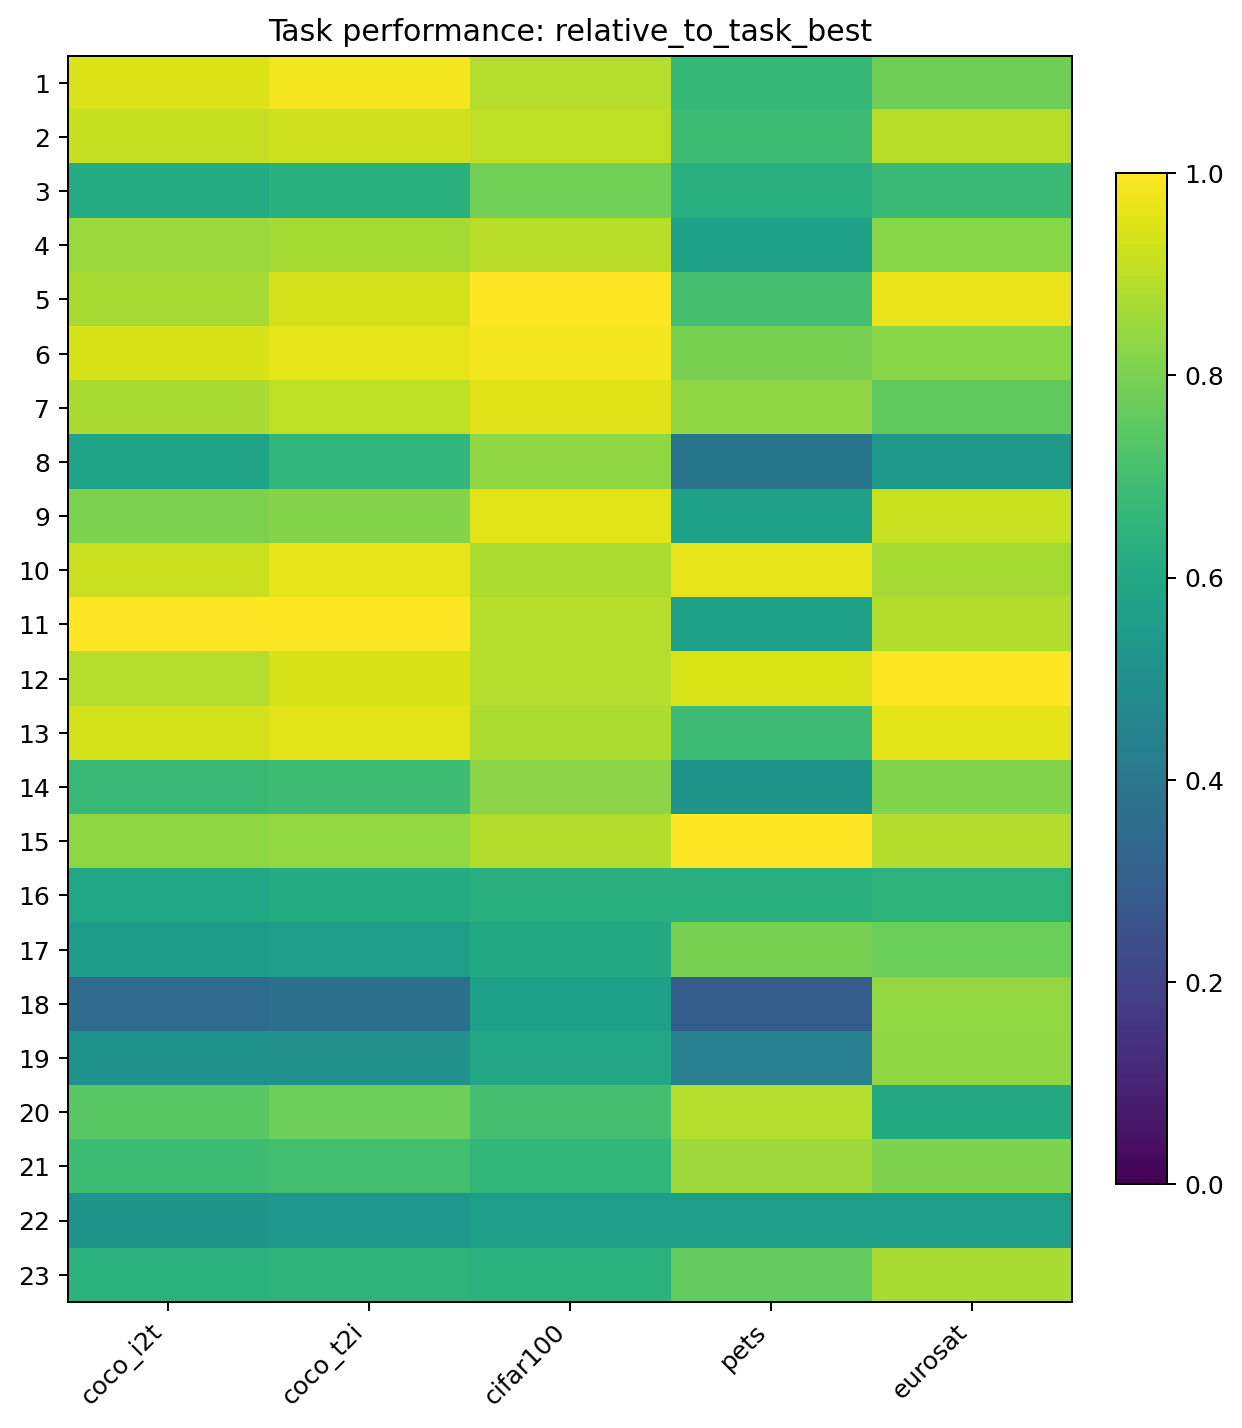

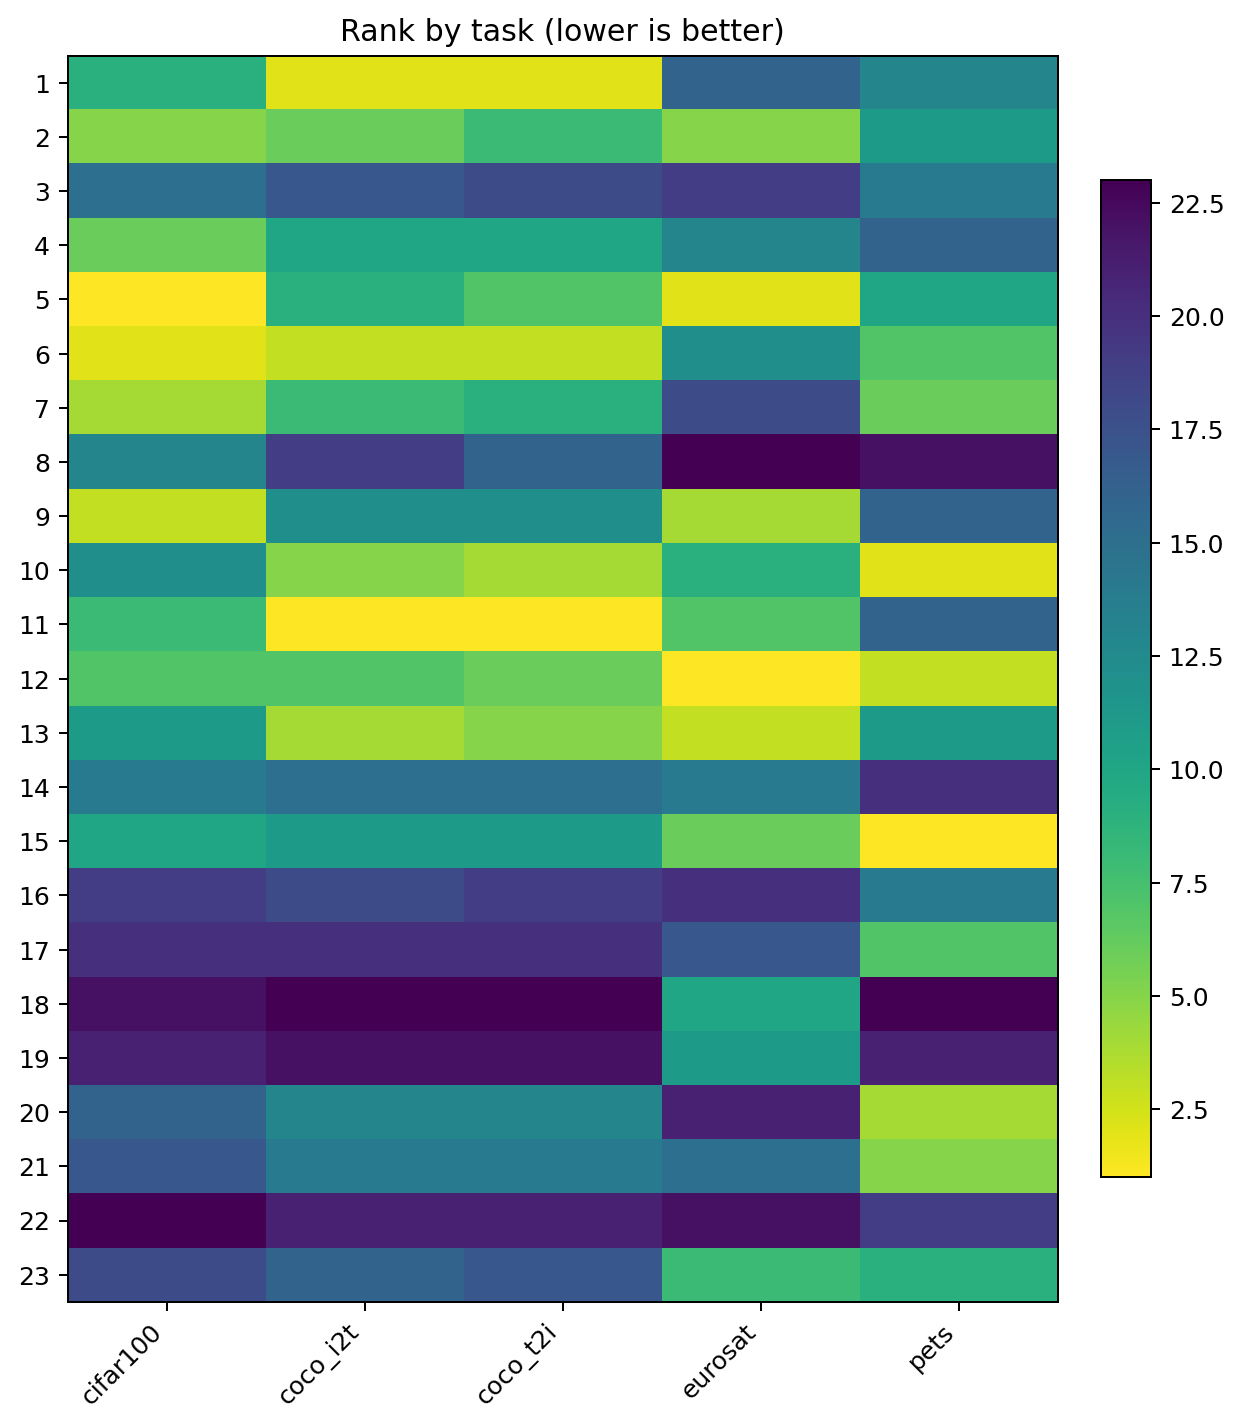

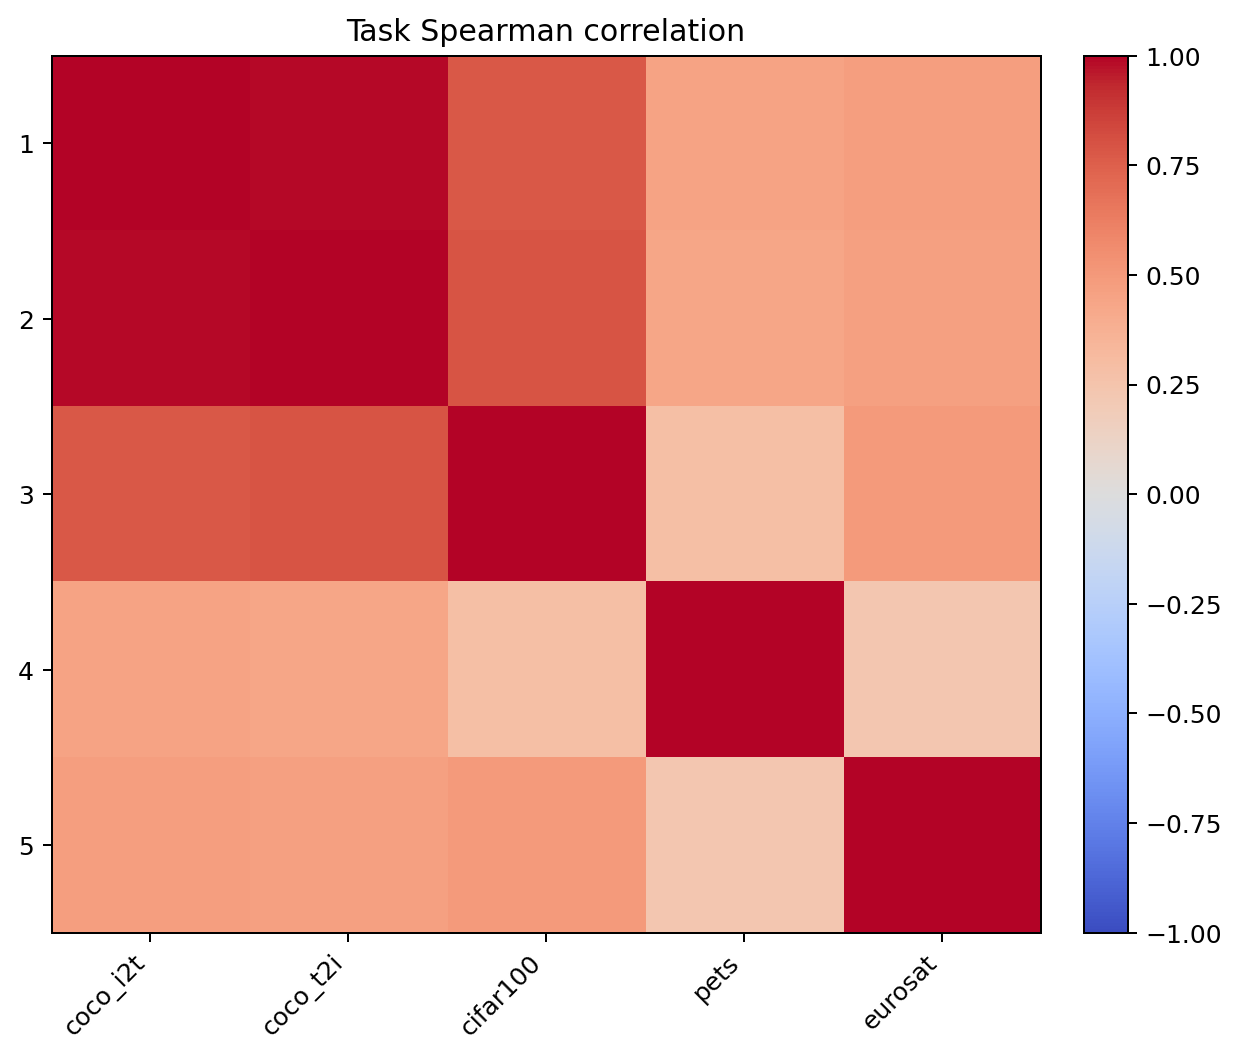

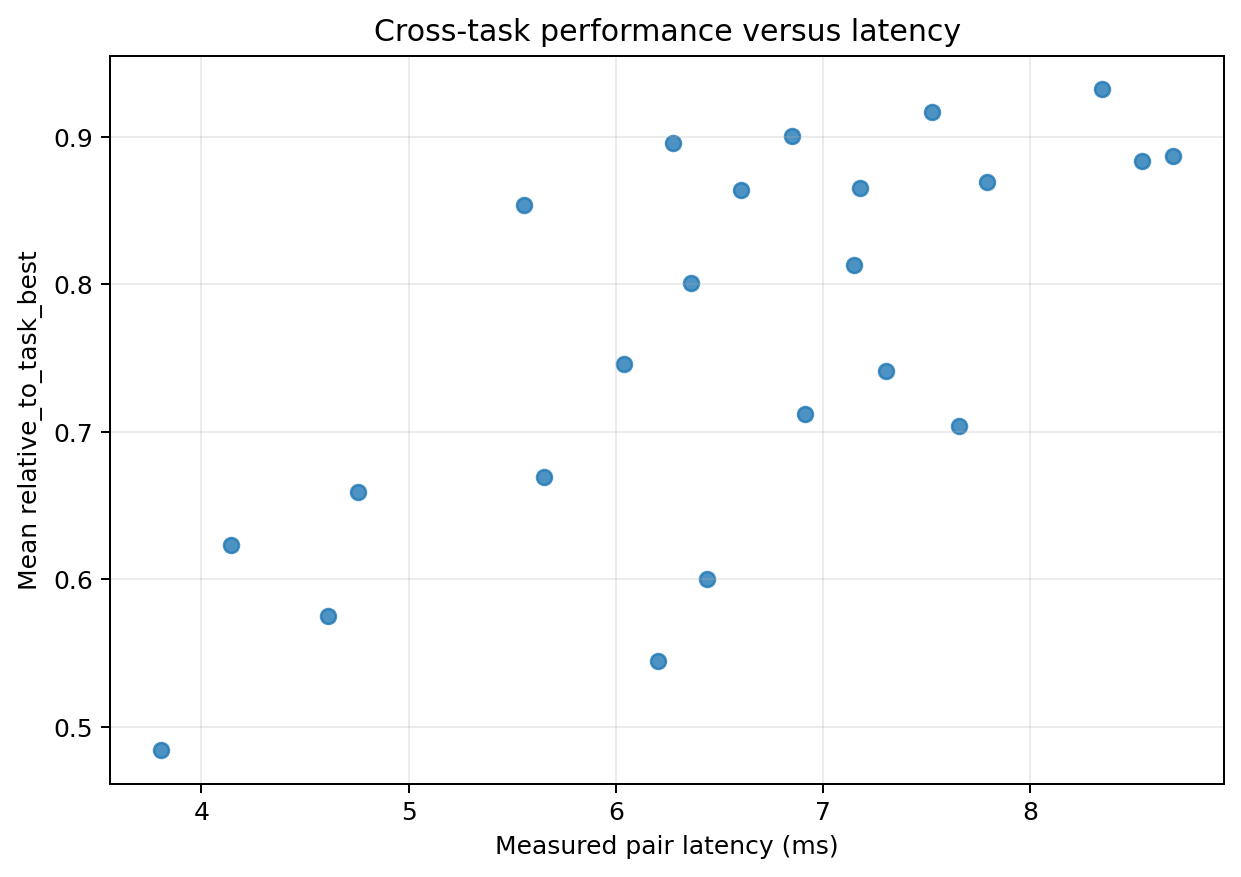

In [6]:
from IPython.display import Image
from src.phase15.runner import run_phase15

VISION_ANCHOR_TEXT = "all_minilm_l6_v2"
TEXT_ANCHOR_VISION = "dinov2_vits14"
phase15_root = PROJECT_ROOT / "results/phase15"
if RUN_PHASE15 and not RESULTS_ONLY:
    phase15 = run_phase15(
        PROJECT_ROOT,
        VISION_ANCHOR_TEXT,
        TEXT_ANCHOR_VISION,
        mode=RUN_MODE,
        strict_validation=(RUN_MODE == "full"),
        materialize_missing_t2i=False,
        reuse_prediction_validation=True,
    )
    display(phase15)
tables = [
    "complementarity/retrieval_pairwise.csv",
    "complementarity/classification_pairwise.csv",
    "complementarity/classification_per_class.csv",
    "oracle/retrieval_oracle.csv",
    "oracle/classification_oracle.csv",
    "oracle/classification_oracle_per_class.csv",
    "cross_task/configuration_rankings.csv",
    "cross_task/expert_specialisation.csv",
    "cross_task/task_rank_correlations.csv",
    "compositional/task_status.csv",
]
for relative in tables:
    path = phase15_root / relative
    if path.exists():
        frame = pd.read_csv(path)
        print(relative, f"({len(frame):,} rows)")
        display(frame.head(25))
    else:
        print("Not yet generated:", path)
for name in ("task_performance_normalised_heatmap.png", "rank_by_task_heatmap.png", "task_correlation_heatmap.png", "performance_vs_latency.png"):
    path = phase15_root / "cross_task" / name
    if path.exists(): display(Image(filename=str(path)))


## Step 15 — Phase 1.5: Encoder Efficiency Profiling

This step profiles canonical frozen encoders and every evaluated baseline/BLF pair using one checkpoint at a time. It records parameters, dimensions, token counts, latency, throughput, peak GPU memory, and supported FLOP/MAC estimates. Resume metadata prevents completed profiles from rerunning. Set both `RUN_PHASE15=True` and `RUN_EFFICIENCY_PROFILING=True` only on the same representative GPU; changing the device or settings intentionally triggers comparable re-profiling. Results-only mode displays existing profiles.


In [7]:
import importlib
import src.phase15.efficiency_profile as efficiency_profile_module
efficiency_profile_module = importlib.reload(efficiency_profile_module)
profile_phase15_efficiency = efficiency_profile_module.profile_phase15_efficiency

efficiency_root = PROJECT_ROOT / "results/phase15/efficiency"
evaluated_results_path = PROJECT_ROOT / "results/phase1_multitask/task_results_long.csv"
if not evaluated_results_path.exists(): raise FileNotFoundError("Run Steps 11 and 11.5 before efficiency profiling.")
evaluated_results = pd.read_csv(evaluated_results_path)
if "mode" in evaluated_results.columns: evaluated_results = evaluated_results[evaluated_results["mode"].eq("full")]
EFFICIENCY_CONFIG_IDS = sorted(evaluated_results["config_id"].dropna().unique())
print(f"Step 15 efficiency scope: {len(EFFICIENCY_CONFIG_IDS)} evaluated full configurations")
if RUN_PHASE15 and RUN_EFFICIENCY_PROFILING and not RESULTS_ONLY:
    if not torch.cuda.is_available(): raise RuntimeError("Step 15 requires a GPU allocation for comparable latency and memory measurements.")
    efficiency = profile_phase15_efficiency(PROJECT_ROOT, device="cuda:0", batch_size=8, warmup=2, repeats=5, measure_flops=True, resume=True, config_ids=EFFICIENCY_CONFIG_IDS)
    display(efficiency)
    if efficiency["status"] != "complete":
        errors_path = efficiency_root / "profiling_errors.csv"
        if errors_path.exists(): display(pd.read_csv(errors_path))
        raise RuntimeError("Step 15 did not complete every evaluated full configuration.")
else:
    print("Profiling not launched. Enable RUN_PHASE15 and RUN_EFFICIENCY_PROFILING with RESULTS_ONLY=False to run it.")
for filename in ("vision_encoders.csv", "text_encoders.csv", "full_pairs.csv", "profiling_errors.csv"):
    path = efficiency_root / filename
    if path.exists():
        frame = pd.read_csv(path)
        print(path, f"({len(frame):,} rows)")
        display(frame)


Step 15 efficiency scope: 23 evaluated full configurations
Profiling not launched. Enable RUN_PHASE15 and RUN_EFFICIENCY_PROFILING with RESULTS_ONLY=False to run it.
/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/efficiency/vision_encoders.csv (5 rows)


,vision_encoder,architecture_family,representative_config,output_dim,image_size,parameters,trainable_parameters,parameter_bytes,device,device_name,...,status,batch_latency_seconds,latency_ms,throughput_batches_per_second,throughput_samples_per_second,peak_allocated_bytes,peak_reserved_bytes,flops,flops_per_batch,macs_estimate_per_batch
0,convnext_tiny,convnext_cnn,convnext_tiny__all_minilm_l6_v2__baseline,768,224,27820128,0,111280512,cuda:0,NVIDIA RTX PRO 6000 Blackwell Server Edition,...,complete,0.004074,4.073609,245.482594,1963.860753,328419840.0,402653184.0,7.127621e+10,7.127621e+10,3.563811e+10
1,convnextv2_tiny,convnext_cnn,convnextv2_tiny__all_minilm_l6_v2__baseline,768,224,27866496,0,111465984,cuda:0,NVIDIA RTX PRO 6000 Blackwell Server Edition,...,complete,0.004839,4.838818,206.662051,1653.296406,367327744.0,517996544.0,7.127621e+10,7.127621e+10,3.563811e+10
2,dinov2_vits14,plain_vit,dinov2_vits14__all_minilm_l6_v2__baseline,384,224,22056576,0,88226304,cuda:0,NVIDIA RTX PRO 6000 Blackwell Server Edition,...,complete,0.006097,6.096576,164.026502,1312.212016,242279936.0,283115520.0,9.797699e+10,9.797699e+10,4.898850e+10
3,efficientnet_b0,efficient_cnn,efficientnet_b0__all_minilm_l6_v2__baseline,1280,224,4007548,0,16030192,cuda:0,NVIDIA RTX PRO 6000 Blackwell Server Edition,...,complete,0.001899,1.899201,526.537147,4212.297173,224102912.0,276824064.0,6.152556e+09,6.152556e+09,3.076278e+09
4,swin_tiny,hierarchical_vit,swin_tiny__all_minilm_l6_v2__baseline,768,224,27519354,0,110077416,cuda:0,NVIDIA RTX PRO 6000 Blackwell Server Edition,...,complete,0.004637,4.636862,215.663074,1725.304591,344954368.0,452984832.0,7.183678e+10,7.183678e+10,3.591839e+10


/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/efficiency/text_encoders.csv (4 rows)


,text_encoder,architecture_family,representative_config,output_dim,mean_tokens,max_tokens,parameters,trainable_parameters,parameter_bytes,device,...,status,batch_latency_seconds,latency_ms,throughput_batches_per_second,throughput_samples_per_second,peak_allocated_bytes,peak_reserved_bytes,flops,flops_per_batch,macs_estimate_per_batch
0,all_minilm_l6_v2,minilm_sentence_transformer,convnext_tiny__all_minilm_l6_v2__baseline,384,9.375,11,22713216,0,90852864,cuda:0,...,complete,0.001704,1.704466,586.694089,4693.552710,224585216.0,402653184.0,1.879843e+09,1.879843e+09,9.399214e+08
1,bge_small_en,bge_embedding_model,convnext_tiny__bge_small_en__baseline,384,9.375,11,33360000,0,133440000,cuda:0,...,complete,0.002475,2.474504,404.121458,3232.971666,265992704.0,306184192.0,3.757326e+09,3.757326e+09,1.878663e+09
2,distilbert,masked_language_model,convnext_tiny__distilbert__baseline,768,9.375,11,66362880,0,265451520,cuda:0,...,complete,0.001572,1.572400,635.970395,5087.763156,403121152.0,444596224.0,7.492092e+09,7.492092e+09,3.746046e+09
3,e5_small_v2,e5_embedding_model,convnext_tiny__e5_small_v2__baseline,384,11.375,13,33360000,0,133440000,cuda:0,...,complete,0.002520,2.519549,396.896361,3175.170888,267927552.0,306184192.0,4.443881e+09,4.443881e+09,2.221941e+09


/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/efficiency/full_pairs.csv (23 rows)


,config_id,vision_encoder,text_encoder,variant,best_epoch,checkpoint,checkpoint_bytes,shared_dim,image_size,parameters,...,status,batch_latency_seconds,latency_ms,throughput_batches_per_second,throughput_samples_per_second,peak_allocated_bytes,peak_reserved_bytes,flops,flops_per_batch,macs_estimate_per_batch
0,convnext_tiny__all_minilm_l6_v2__baseline,convnext_tiny,all_minilm_l6_v2,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,218817210,256,224,51913185,...,complete,0.005557,5.557093,179.950215,1439.601719,328419840.0,402653184.0,7.317811e+10,7.317811e+10,3.658905e+10
1,convnext_tiny__bge_small_en__baseline,convnext_tiny,bge_small_en,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,261440282,256,224,62559969,...,complete,0.006605,6.604636,151.408803,1211.270422,369827328.0,421527552.0,7.505559e+10,7.505559e+10,3.752780e+10
2,convnext_tiny__distilbert__baseline,convnext_tiny,distilbert,baseline,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,395769353,256,224,95759457,...,complete,0.005651,5.651046,176.958402,1415.667220,504179712.0,559939584.0,7.879350e+10,7.879350e+10,3.939675e+10
3,convnext_tiny__e5_small_v2__baseline,convnext_tiny,e5_small_v2,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,261440282,256,224,62559969,...,complete,0.006364,6.364456,157.122624,1256.980994,371564032.0,421527552.0,7.574215e+10,7.574215e+10,3.787107e+10
4,convnextv2_tiny__all_minilm_l6_v2__baseline,convnextv2_tiny,all_minilm_l6_v2,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,219007904,256,224,51959553,...,complete,0.006277,6.276567,159.322764,1274.582108,367327744.0,520093696.0,7.317811e+10,7.317811e+10,3.658905e+10
5,convnextv2_tiny__all_minilm_l6_v2__local_global,convnextv2_tiny,all_minilm_l6_v2,local_global,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,221155704,256,224,52135425,...,complete,0.006848,6.848302,146.021597,1168.172779,367886848.0,520093696.0,7.396887e+10,7.396887e+10,3.698443e+10
6,convnextv2_tiny__bge_small_en__baseline,convnextv2_tiny,bge_small_en,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,261630912,256,224,62606337,...,complete,0.007177,7.176864,139.336628,1114.693026,410832384.0,501219328.0,7.505559e+10,7.505559e+10,3.752780e+10
7,convnextv2_tiny__distilbert__baseline,convnextv2_tiny,distilbert,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,395962671,256,224,95805825,...,complete,0.006440,6.440120,155.276614,1242.212913,544365568.0,637534208.0,7.879350e+10,7.879350e+10,3.939675e+10
8,convnextv2_tiny__e5_small_v2__baseline,convnextv2_tiny,e5_small_v2,baseline,1,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,261630912,256,224,62606337,...,complete,0.007147,7.147458,139.909888,1119.279107,410832384.0,501219328.0,7.574215e+10,7.574215e+10,3.787107e+10
9,dinov2_vits14__all_minilm_l6_v2__baseline,dinov2_vits14,all_minilm_l6_v2,baseline,2,/mnt/fast/nobackup/scratch4weeks/pp01184/align...,193416995,256,224,45953025,...,complete,0.007526,7.525923,132.874059,1062.992472,242279936.0,285212672.0,9.987574e+10,9.987574e+10,4.993787e+10


## Step 16 — Phase 1.5: Diagnostic and Training-Split Hard Negatives

This step keeps the existing held-out COCO-validation and classification-test hard negatives as immutable **diagnostic-only** evidence (`allowed_for_training=false`). A separate, explicitly gated path mines future training candidates from COCO train2017, deterministic CIFAR-100-train and Pets-trainval partitions, and the stored EuroSAT train split. It excludes same-image captions and normalised duplicate captions, validates zero protected-test-ID overlap, and dispatches one selected expert pair per visible GPU. Retrieval caches, retrieval shards, and classification shards resume independently; final combined outputs are published only after every worker succeeds. Full training-negative mining requires both mining switches and at least one GPU; Run All never launches it.

| GPUs | Execution for the four selected pairs | Trade-off |
|---:|---|---|
| 1 | Four pairs run sequentially | Lowest resource use and longest wall time. |
| 2 | Two pairs run concurrently in two waves | Roughly halves pair-level wall time, subject to shared storage throughput. |
| 4 | All four pairs run concurrently | Best fit for the current shortlist; highest useful throughput. |
| 8 | Four GPUs run and four remain idle | No pair-level speed-up beyond four GPUs unless the shortlist grows. |


In [ ]:
import json
import signal, subprocess
from src.phase15.hard_negative_mining import run_hard_negative_mining, write_diagnostic_metadata

HARD_NEGATIVES_PER_POSITIVE = 8
diagnostic_root = PROJECT_ROOT / "results/phase15/hard_negatives"
training_root = PROJECT_ROOT / "results/phase15/training_hard_negatives"
if RUN_PHASE15 and RUN_DIAGNOSTIC_HARD_NEGATIVE_MINING and not RESULTS_ONLY:
    mining_device = "cuda:0" if torch.cuda.is_available() else "cpu"
    diagnostic = run_hard_negative_mining(PROJECT_ROOT, count=HARD_NEGATIVES_PER_POSITIVE, classification_count=1, config_limit=3, chunk_size=128, device=mining_device, resume=True)
    display(diagnostic)
elif (diagnostic_root / "hard_negative_summary.json").exists():
    print("Reusing historical held-out diagnostic negatives; no recomputation launched.")
if RUN_PHASE15 and not RESULTS_ONLY and (diagnostic_root / "hard_negative_summary.json").exists():
    print("Diagnostic restriction sidecar:", write_diagnostic_metadata(PROJECT_ROOT))
if RUN_PHASE15 and RUN_TRAINING_HARD_NEGATIVE_MINING and not RESULTS_ONLY:
    if not GPU_IDS:
        raise RuntimeError("Full Step 16 mining requires at least one allocated GPU.")
    training_cmd = [
        PYTHON,
        "scripts/run_training_hard_negative_jobs.py",
        "--mode", RUN_MODE,
        "--count", str(HARD_NEGATIVES_PER_POSITIVE),
        "--chunk-size", "128",
        "--gpus", *GPU_IDS,
        "--resume",
    ]
    print("Multi-GPU training-negative command:", " ".join(training_cmd), flush=True)
    training_process = subprocess.Popen(training_cmd, cwd=PROJECT_ROOT, start_new_session=True)
    try:
        training_returncode = training_process.wait()
    except KeyboardInterrupt:
        print("Stopping the Step 16 coordinator and its GPU workers...", flush=True)
        try:
            os.killpg(training_process.pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
        try:
            training_process.wait(timeout=60)
        except subprocess.TimeoutExpired:
            try:
                os.killpg(training_process.pid, signal.SIGKILL)
            except ProcessLookupError:
                pass
            training_process.wait()
        raise
    if training_returncode != 0:
        raise subprocess.CalledProcessError(training_returncode, training_cmd)
else:
    print("Training-negative mining not launched. It requires RUN_PHASE15=True, RUN_TRAINING_HARD_NEGATIVE_MINING=True, and RESULTS_ONLY=False.")
for path in (diagnostic_root / "hard_negative_summary.json", diagnostic_root / "diagnostic_metadata.json", training_root / "coordinator_state.json", training_root / "schema.json", training_root / "compositional_training_manifest.json"):
    if path.exists():
        print(path)
        display(json.loads(path.read_text()))
for path in (diagnostic_root / "hard_negative_manifest.csv", training_root / "mining_summary.csv"):
    if path.exists():
        print(path)
        display(pd.read_csv(path))


Reusing historical held-out diagnostic negatives; no recomputation launched.
Diagnostic restriction sidecar: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/hard_negatives/diagnostic_metadata.json
Multi-GPU training-negative command: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/run_training_hard_negative_jobs.py --mode full --count 8 --chunk-size 128 --gpus 0 1 2 3 --resume
Partial resume convnext_tiny__all_minilm_l6_v2__baseline: retrieval=ready, classification=pending
Running 4 pending configuration(s) across 4 GPU(s): 0, 1, 2, 3
Per-worker logs: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/logs/phase15/hard_negative_mining/1784613401_1057945
[GPU 0] started 1/4: dinov2_vits14__all_minilm_l6_v2__baseline
[GPU 1] started 2/4: dinov2_vits14__bge_small_en__baseline
[GPU 2] started 3/4: convnext_tiny__all_minilm_l6_v2__baseline
[GPU 3] started 4/4: efficientnet_b0__bge_small_en__baseline
[GPU 0 | dinov2_vits14__all_minil

## Step 17 — Phase 1.5: Diversity-Constrained Expert Selection and Readiness

This step joins canonical multi-task, complementarity, oracle, cross-task, seed-reliability, and measured-efficiency evidence. Weighted scoring is followed by hard diversity and cost constraints, with cheap fallbacks and explicit exclusions; inconclusive BLF variants cannot duplicate a baseline in primary slots. It writes the sole future machine-readable selection file, `selected_experts.yaml`, then runs the 22-check readiness gate. Historical test-derived selection remains exploratory and must not pass the development-protocol check. No router, adaptive fusion, cross-attention, controller, or Phase 2 training is implemented here.


In [11]:
import json
import pandas as pd
from src.phase15.expert_selection import run_expert_selection
from src.phase15.phase2_readiness import run_phase2_readiness

selection_root = PROJECT_ROOT / "results/phase15/expert_selection"
readiness_root = PROJECT_ROOT / "results/phase15/phase2_readiness"
methodology_root = PROJECT_ROOT / "results/phase15/methodology"
if RUN_PHASE15 and not RESULTS_ONLY:
    expert_selection = run_expert_selection(PROJECT_ROOT, vision_limit=3, text_limit=3, pair_limit=6)
    display(expert_selection)
    readiness = run_phase2_readiness(PROJECT_ROOT)
    display(readiness)
else:
    print("Selection/readiness not recomputed; displaying saved outputs where available.")
for filename in ("vision_experts_ranked.csv", "text_experts_ranked.csv", "pairs_ranked.csv", "pair_shortlist.csv"):
    path = selection_root / filename
    if path.exists():
        frame = pd.read_csv(path)
        print(filename, f"({len(frame):,} rows)")
        display(frame.head(30))
for path in (selection_root / "selection_diagnostics.json", readiness_root / "readiness_report.json"):
    if path.exists():
        print(path)
        display(json.loads(path.read_text()))
for path in (methodology_root / "data_usage_table.csv", readiness_root / "readiness_checks.csv"):
    if path.exists():
        print(path)
        display(pd.read_csv(path))
canonical_selection = selection_root / "selected_experts.yaml"
print("Canonical future Phase 2 selection input:", canonical_selection)
if not canonical_selection.exists(): print("Not yet generated: run Steps 13–17 under the frozen development protocol.")


Selection/readiness not recomputed; displaying saved outputs where available.
vision_experts_ranked.csv (5 rows)


,vision_encoder,multitask_performance_score,best_pair_performance,unique_win_contribution,oracle_contribution,cross_task_specialisation,seed_reliability_score,seed_evidence_pairs,selection_score,architecture_family,latency_ms,peak_allocated_bytes,parameters,output_dim,token_interface_expected,latency_score,memory_score,efficiency_score,best_pair,reliability_status
0,dinov2_vits14,0.693478,0.834783,0.108892,0.007763,0.085456,0.416667,2,0.602880,plain_vit,6.096576,242279936.0,22056576,384,True,0.2,0.8,0.44,dinov2_vits14__all_minilm_l6_v2__local,inconclusive
1,convnext_tiny,0.571739,0.734783,0.098163,0.005443,0.096094,0.250000,0,0.578437,convnext_cnn,4.073609,328419840.0,27820128,768,True,0.8,0.6,0.72,convnext_tiny__all_minilm_l6_v2__baseline,not_tested
2,efficientnet_b0,0.232609,0.308696,0.066925,0.004328,0.115464,0.250000,0,0.570829,efficient_cnn,1.899201,224102912.0,4007548,1280,True,1.0,1.0,1.00,efficientnet_b0__bge_small_en__baseline,not_tested
3,convnextv2_tiny,0.621739,0.804348,0.098970,0.004839,0.105680,0.450000,2,0.481951,convnext_cnn,4.838818,367327744.0,27866496,768,True,0.4,0.2,0.32,convnextv2_tiny__all_minilm_l6_v2__baseline,supported
4,swin_tiny,0.378261,0.478261,0.079871,0.006416,0.068513,0.250000,0,0.466318,hierarchical_vit,4.636862,344954368.0,27519354,768,True,0.6,0.4,0.52,swin_tiny__e5_small_v2__baseline,not_tested


text_experts_ranked.csv (4 rows)


,text_encoder,multitask_performance_score,best_pair_performance,unique_win_contribution,oracle_contribution,cross_task_specialisation,seed_reliability_score,seed_evidence_pairs,selection_score,architecture_family,latency_ms,peak_allocated_bytes,parameters,output_dim,token_interface_expected,latency_score,memory_score,efficiency_score,best_pair,reliability_status
0,all_minilm_l6_v2,0.643478,0.804348,0.102370,0.005419,0.085886,0.535714,4,0.682147,minilm_sentence_transformer,1.704466,224585216.0,22713216,384,True,0.75,1.00,0.85,dinov2_vits14__all_minilm_l6_v2__local,inconclusive
1,bge_small_en,0.625362,0.834783,0.099868,0.006346,0.080430,0.250000,0,0.584226,bge_embedding_model,2.474504,265992704.0,33360000,384,True,0.50,0.75,0.60,dinov2_vits14__bge_small_en__baseline,not_tested
2,e5_small_v2,0.507826,0.704348,0.091149,0.005539,0.108327,0.250000,0,0.469250,e5_embedding_model,2.519549,267927552.0,33360000,384,True,0.25,0.50,0.35,dinov2_vits14__e5_small_v2__baseline,not_tested
3,distilbert,0.240870,0.365217,0.071299,0.006364,0.107201,0.250000,0,0.452549,masked_language_model,1.572400,403121152.0,66362880,768,True,1.00,0.25,0.70,dinov2_vits14__distilbert__baseline,not_tested


pairs_ranked.csv (23 rows)


...

/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/methodology/data_usage_table.csv


,dataset,task,train_split,development_split,selection_split,final_test_split,used_for_checkpoint_selection,used_for_expert_selection,used_for_final_reporting,historical_result_status
0,coco,retrieval,train2017,val2017,val2017,flickr30k_external_if_available,True,True,False,exploratory_development
1,cifar100,classification,official_train_train_partition,deterministic_official_train_development_parti...,deterministic_official_train_development_parti...,official_test,False,True,True,exploratory_development_test_used
2,oxford_iiit_pet,classification,deterministic_trainval_train_partition,deterministic_trainval_development_partition,deterministic_trainval_development_partition,official_test,False,True,True,exploratory_development_test_used
3,eurosat,classification,deterministic_stratified_train,deterministic_stratified_development,deterministic_stratified_development,deterministic_stratified_test,False,True,True,exploratory_development_complete_dataset_used
4,winoground,compositional,unavailable,unavailable,evaluation_only,evaluation_only,False,False,True,unavailable_or_evaluation_only
5,sugarcrepe,compositional,unavailable,unavailable,evaluation_only,evaluation_only,False,False,True,unavailable_or_evaluation_only


/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/phase2_readiness/readiness_checks.csv


,check_number,check,severity,passed,details
0,1,safe notebook defaults,required,False,"observed={'RUN_PHASE1_TRAINING': False, 'RUN_S..."
1,2,canonical retrieval results,required,True,valid
2,3,seed-sweep results,required,True,valid
3,4,multi-task development outputs,required,True,valid
4,5,strict prediction coverage,required,True,115/115 exports valid
5,6,retrieval complementarity,required,True,valid
6,7,classification complementarity,required,True,valid
7,8,retrieval oracle,required,True,valid
8,9,classification oracle,required,True,valid
9,10,cross-task matrix,required,True,valid


Canonical future Phase 2 selection input: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/expert_selection/selected_experts.yaml


In [12]:
from src.phase15.phase2_readiness import run_phase2_readiness

final_readiness = run_phase2_readiness(PROJECT_ROOT)
display(final_readiness)

print("Status:", final_readiness["status"])
print("Ready:", final_readiness["ready_to_implement_phase2"])
print("Required failures:", final_readiness["required_failures"])

{'status': 'READY',
 'ready_to_implement_phase2': True,
 'required_failures': 0,
 'warnings': 0,
 'checks': [{'check_number': 1,
   'check': 'safe notebook defaults',
   'severity': 'required',
   'passed': True,
   'details': "observed={'RUN_PHASE1_TRAINING': False, 'RUN_SEED_SWEEP': False, 'RUN_QUALITATIVE_RETRIEVAL': False, 'RUN_MULTITASK_EVALUATION': False, 'RUN_PHASE15': False, 'RUN_DEVELOPMENT_EVALUATION': False, 'RUN_EFFICIENCY_PROFILING': False, 'RUN_DIAGNOSTIC_HARD_NEGATIVE_MINING': False, 'RUN_TRAINING_HARD_NEGATIVE_MINING': False, 'RUN_MODE': 'smoke', 'RESULTS_ONLY': True}"},
  {'check_number': 2,
   'check': 'canonical retrieval results',
   'severity': 'required',
   'passed': True,
   'details': 'valid'},
  {'check_number': 3,
   'check': 'seed-sweep results',
   'severity': 'required',
   'passed': True,
   'details': 'valid'},
  {'check_number': 4,
   'check': 'multi-task development outputs',
   'severity': 'required',
   'passed': True,
   'details': 'valid'},
  {'che

Status: READY
Ready: True
Required failures: 0


## Sanctity check

Freeze and archive the current selected_experts.yaml, evaluation protocol, and readiness report so the Phase 2 shortlist cannot drift after seeing later test outcomes

In [3]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil
import subprocess

PROJECT_ROOT = Path(PROJECT_ROOT).resolve()

# Create a uniquely versioned Phase 1.5 snapshot.
timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
archive_root = (
    PROJECT_ROOT
    / "results"
    / "phase15"
    / "frozen_snapshots"
    / f"phase15_locked_{timestamp}"
)

required_files = [
    PROJECT_ROOT / "results/phase15/expert_selection/selected_experts.yaml",
    PROJECT_ROOT / "configs/evaluation_protocol.yaml",
    PROJECT_ROOT / "results/phase15/phase2_readiness/readiness_report.json",
    PROJECT_ROOT / "results/phase15/phase2_readiness/readiness_report.md",
    PROJECT_ROOT / "results/phase15/phase2_readiness/readiness_checks.csv",
]

supporting_files = [
    PROJECT_ROOT / "results/phase15/expert_selection/pair_shortlist.csv",
    PROJECT_ROOT / "results/phase15/expert_selection/selection_explanation.md",
    PROJECT_ROOT / "results/phase15/expert_selection/selection_diagnostics.json",
]

missing_required = [str(path) for path in required_files if not path.exists()]

if missing_required:
    raise FileNotFoundError(
        "Cannot freeze Phase 1.5 because required files are missing:\n"
        + "\n".join(missing_required)
    )

archive_root.mkdir(parents=True, exist_ok=False)

copied_files = []

for source in required_files + supporting_files:
    if not source.exists():
        print(f"Optional supporting file missing: {source}")
        continue

    relative_path = source.relative_to(PROJECT_ROOT)
    destination = archive_root / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source, destination)
    copied_files.append(destination)

# Create SHA-256 hashes so later modifications are detectable.
hashes = {}

for file_path in copied_files:
    digest = hashlib.sha256(file_path.read_bytes()).hexdigest()
    hashes[str(file_path.relative_to(archive_root))] = digest

hash_file = archive_root / "SHA256SUMS.json"
hash_file.write_text(json.dumps(hashes, indent=2), encoding="utf-8")

# Record the current Git commit when available.
try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True,
    ).strip()
except Exception:
    git_commit = None

manifest = {
    "snapshot_name": archive_root.name,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "research_phase": "Phase 1.5 complete; Phase 2 not yet started",
    "research_question": (
        "Can multiple lightweight pretrained vision and text encoders "
        "be adaptively combined across multiple vision-language tasks "
        "to achieve a better performance–efficiency trade-off than a "
        "single fixed encoder pair?"
    ),
    "git_commit": git_commit,
    "canonical_expert_selection": (
        "results/phase15/expert_selection/selected_experts.yaml"
    ),
    "files": sorted(hashes),
    "phase2_policy": (
        "The selected expert pool and evaluation protocol must not be "
        "changed after observing Phase 2 final-test results. Any later "
        "change requires a new explicitly versioned snapshot."
    ),
}

manifest_path = archive_root / "SNAPSHOT_MANIFEST.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

# Optional filesystem protection against accidental edits.
for file_path in copied_files + [hash_file, manifest_path]:
    file_path.chmod(0o444)

print("Phase 1.5 snapshot created successfully.")
print(f"Archive: {archive_root}")
print(f"Files archived: {len(copied_files)}")
print(f"Git commit: {git_commit or 'not available'}")
print(f"Manifest: {manifest_path}")
print(f"Hashes: {hash_file}")

Phase 1.5 snapshot created successfully.
Archive: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/frozen_snapshots/phase15_locked_20260721T150149Z
Files archived: 8
Git commit: not available
Manifest: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/frozen_snapshots/phase15_locked_20260721T150149Z/SNAPSHOT_MANIFEST.json
Hashes: /mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/results/phase15/frozen_snapshots/phase15_locked_20260721T150149Z/SHA256SUMS.json


fatal: not a git repository (or any parent up to mount point /mnt/fast/nobackup)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


## Extract Embeddings for One Configuration


In [11]:
checkpoint = "checkpoints/efficientnet_b0_minilm_l6_local_global/best.pt"
embedding_dir = "embeddings/efficientnet_b0_minilm_l6_local_global"
extract_cmd = [
    PYTHON, "scripts/extract_embeddings.py",
    "--config", CONFIG,
    "--checkpoint", checkpoint,
    "--output_dir", embedding_dir,
]
print(" ".join(extract_cmd))

/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/bin/python scripts/extract_embeddings.py --config configs/coco_blf_rtxpro.yaml --checkpoint checkpoints/efficientnet_b0_minilm_l6_local_global/best.pt --output_dir embeddings/efficientnet_b0_minilm_l6_local_global


# Phase 2

## Phase 2 Setup and Smoke-Test Controls

Phase 2 keeps every pretrained vision and text backbone frozen and trains only token adapters, lightweight text-to-vision cross-attention bridges, scoring heads, and the dense task-conditioned combination module. The notebook runs bounded smoke tests and displays saved results; all complete experiments are submitted through the dependency-chained Slurm pipeline.


In [3]:
RUN_PHASE2_SMOKE_TESTS = False
RUN_PHASE2_DDP_SMOKE_TEST = False
PHASE2_SMOKE_MAX_BATCHES = 2
PHASE2_SMOKE_MAX_SAMPLES = 32
PHASE2_SMOKE_EPOCHS = 1
PHASE2_ROOT = PROJECT_ROOT / 'results/phase2'
PHASE2_SUBMIT_COMMAND = 'bash scripts/submit_phase2_pipeline.sh --max-total-gpus 8'
print('Smoke tests enabled:', RUN_PHASE2_SMOKE_TESTS)
print('Optional two-GPU DDP smoke enabled:', RUN_PHASE2_DDP_SMOKE_TEST)
print('Full Phase 2 submission (not executed here):', PHASE2_SUBMIT_COMMAND)


Smoke tests enabled: True
Optional two-GPU DDP smoke enabled: False
Full Phase 2 submission (not executed here): bash scripts/submit_phase2_pipeline.sh --max-total-gpus 8


## Phase 2 Prerequisite Smoke Test

Checks the locked Phase 1.5 readiness, selection fingerprints, checkpoints, datasets, and zero protected-test overlap without changing the expert shortlist.


In [6]:

from src.phase2.prerequisites import validate_phase2_prerequisites
phase2_prerequisites = validate_phase2_prerequisites(PROJECT_ROOT, write=False)
display(pd.DataFrame(phase2_prerequisites['checks']))
print('Prerequisite status:', phase2_prerequisites['status'])


,check,severity,passed,details
0,phase15_readiness,required,True,READY
1,locked_selection_exists,required,True,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
2,frozen_snapshot_exists,required,True,/mnt/fast/nobackup/scratch4weeks/pp01184/align...
3,snapshot_fingerprints,required,True,matched
4,primary_checkpoints,required,True,paths=4 missing=[]
5,encoder_registry,required,True,all registered
6,efficiency_tables,required,True,['/mnt/fast/nobackup/scratch4weeks/pp01184/ali...
7,training_hard_negatives,required,True,retrieval=True classification=True status=comp...
8,zero_protected_overlap,required,True,0
9,evaluation_protocol,required,True,present


Prerequisite status: VALID


## Token-Interface Smoke Test

When enabled on a GPU, validates projected vision/text token shapes, real attention masks, finite values, frozen backbone parameters, adapter gradients, and memory for one selected primary path.


In [7]:
if RUN_PHASE2_SMOKE_TESTS:
    from src.phase2.config import load_phase2_config
    from src.phase2.token_validation import validate_token_interfaces
    token_smoke = validate_token_interfaces(PROJECT_ROOT, load_phase2_config(PROJECT_ROOT / 'configs/phase2/token_interfaces.yaml'), limit=1)
    display(token_smoke)
else:
    print('Token-interface smoke is disabled; no model was loaded.')


/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/fast/nobackup/scratch4weeks/pp01184/alignment_vlm/.venv/lib64/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'status': 'PASS', 'pairs': 1, 'device': 'cuda:0'}

## Cross-Attention Forward/Backward Smoke Test

Runs a bounded synthetic token projection, text-to-vision attention, pair scorer, combined loss, and backward pass while checking gradients and NaNs.


In [8]:
if RUN_PHASE2_SMOKE_TESTS:
    from src.phase2.smoke import run_synthetic_smoke
    phase2_smoke = run_synthetic_smoke(PROJECT_ROOT)
    display(phase2_smoke)
else:
    print('Cross-attention forward/backward smoke is disabled.')


{'status': 'PASS',
 'device': 'cuda:0',
 'loss': 1.0129338502883911,
 'trainable_gradients': 30,
 'dense_weights_sum_to_one': True,
 'reranked_shape': [3, 4],
 'checkpoint_roundtrip': True,
 'peak_memory_bytes': 210179072}

## Tiny Training Smoke Test

The preceding bounded smoke performs one optimizer-compatible backward pass plus an atomic checkpoint round trip. Complete bridge training is deliberately absent from this notebook.


In [9]:
print('Tiny limits:', {'samples': PHASE2_SMOKE_MAX_SAMPLES, 'batches': PHASE2_SMOKE_MAX_BATCHES, 'epochs': PHASE2_SMOKE_EPOCHS})
print('Full training is sbatch-only.')


Tiny limits: {'samples': 32, 'batches': 2, 'epochs': 1}
Full training is sbatch-only.


## Tiny Reranking Smoke Test

Validates that only dual-encoder top-K candidates are rescored and that retrieval/classification reranking shapes and candidate coverage are well formed.


In [10]:
if RUN_PHASE2_SMOKE_TESTS:
    import torch
    from src.phase2.retrieval_reranker import rerank_topk
    dual = torch.randn(4, 12)
    ranked, reranked_scores = rerank_topk(dual, lambda q, c: dual[q, c], depth=4)
    print('Tiny retrieval reranking:', ranked.shape, reranked_scores.shape)
else:
    print('Tiny reranking smoke is disabled.')


Tiny retrieval reranking: torch.Size([4, 4]) torch.Size([4, 4])


## Optional Two-GPU DDP Smoke Test

The DDP smoke must be launched with the supplied two-GPU Slurm script. This cell only checks visibility and prints the exact command; it never creates a distributed allocation itself.


In [ ]:
print('Visible GPUs:', torch.cuda.device_count())
print('Submit DDP smoke:', 'sbatch slurm/phase2/03b_smoke_ddp.sbatch')
if RUN_PHASE2_DDP_SMOKE_TEST:
    print('Use the command above; notebook-side torchrun is intentionally blocked.')


## Slurm Script and Manifest Validation

Performs non-submitting validation and prints the dry-run and full pipeline commands.


In [11]:
phase2_slurm = sorted((PROJECT_ROOT / 'slurm/phase2').glob('*.sbatch'))
display(pd.DataFrame({'script': [str(path.relative_to(PROJECT_ROOT)) for path in phase2_slurm], 'teaching': ['#SBATCH --partition=teaching' in path.read_text() for path in phase2_slurm]}))
print('Dry run:', 'bash scripts/submit_phase2_pipeline.sh --dry-run --max-total-gpus 8')
print('Full submission:', PHASE2_SUBMIT_COMMAND)


,script,teaching
0,slurm/phase2/00_validate_prerequisites.sbatch,True
1,slurm/phase2/01_validate_token_interfaces.sbatch,True
2,slurm/phase2/02_build_training_data.sbatch,True
3,slurm/phase2/03_smoke_cross_attention.sbatch,True
4,slurm/phase2/03b_smoke_ddp.sbatch,True
5,slurm/phase2/04_train_bridges_array.sbatch,True
6,slurm/phase2/05_evaluate_bridges_array.sbatch,True
7,slurm/phase2/06_run_ablations_array.sbatch,True
8,slurm/phase2/07_train_dense_teacher.sbatch,True
9,slurm/phase2/08_evaluate_dense_teacher.sbatch,True


Dry run: bash scripts/submit_phase2_pipeline.sh --dry-run --max-total-gpus 8
Full submission: bash scripts/submit_phase2_pipeline.sh --max-total-gpus 8


## Phase 2 Pipeline Status

Displays the submission manifest, current collected stage status, failure summary, and exact log/traceback locations without launching work.


In [ ]:
import json
for path in [PHASE2_ROOT / 'slurm/submission_manifest.json', PHASE2_ROOT / 'slurm/pipeline_status.json']:
    if path.exists(): print(path); display(json.loads(path.read_text()))
    else: print('Missing (pipeline may not have run yet):', path)
print('Failure report:', PHASE2_ROOT / 'slurm/failure_report.md')
print('Tracebacks:', PHASE2_ROOT / '**/traceback.txt')


## Token-Interface Results


In [ ]:
path = PHASE2_ROOT / 'token_interfaces/token_interface_manifest.csv'
display(pd.read_csv(path)) if path.exists() else print('Missing:', path)


## Phase 2 Training-Data Summary


In [ ]:
path = PHASE2_ROOT / 'data/data_summary.csv'
display(pd.read_csv(path)) if path.exists() else print('Missing:', path)
leakage = PHASE2_ROOT / 'data/leakage_report.json'
display(json.loads(leakage.read_text())) if leakage.exists() else print('Missing:', leakage)


## Cross-Attention Bridge Results

Loads one-GPU bridge training summaries and best checkpoints produced by the Slurm array.


In [ ]:
summaries = sorted((PHASE2_ROOT / 'bridges/runs').glob('*/summary.json')) if (PHASE2_ROOT / 'bridges/runs').exists() else []
display(pd.DataFrame([json.loads(path.read_text()) for path in summaries])) if summaries else print('No completed bridge summaries yet.')


## Two-Stage Reranking Results


In [ ]:
files = sorted((PHASE2_ROOT / 'reranking/runs').glob('*/results.csv')) if (PHASE2_ROOT / 'reranking/runs').exists() else []
display(pd.concat([pd.read_csv(path) for path in files], ignore_index=True)) if files else print('No reranking results yet.')


## Cross-Attention Ablations


In [ ]:
files = sorted((PHASE2_ROOT / 'ablations/runs').glob('*/results.csv')) if (PHASE2_ROOT / 'ablations/runs').exists() else []
display(pd.concat([pd.read_csv(path) for path in files], ignore_index=True)) if files else print('No ablation results yet.')


## Dense Task-Conditioned Teacher Results


In [ ]:
for name in ['results_best.csv', 'path_statistics.csv']:
    path = PHASE2_ROOT / 'dense_teacher' / name
    display(pd.read_csv(path)) if path.exists() else print('Missing:', path)


## Multi-Seed Reliability


In [ ]:
for name in ['phase2_seed_results.csv', 'phase2_statistics.csv']:
    path = PHASE2_ROOT / name
    display(pd.read_csv(path)) if path.exists() else print('Missing:', path)


## Phase 2 Efficiency Comparison


In [ ]:
files = sorted(PHASE2_ROOT.glob('**/efficiency.csv'))
display(pd.concat([pd.read_csv(path) for path in files], ignore_index=True)) if files else print('No Phase 2 efficiency tables yet.')


## Phase 2 Pareto Frontier


In [ ]:
path = PHASE2_ROOT / 'phase2_pareto_frontier.csv'
display(pd.read_csv(path)) if path.exists() else print('Missing:', path)


## Phase 2 Findings

This section displays the generated report only after the Slurm pipeline has completed; conclusions are never fabricated from missing outputs.


In [ ]:
path = PHASE2_ROOT / 'phase2_report.md'
display(Markdown(path.read_text())) if path.exists() else print('Missing:', path)


## Phase 3 Readiness

Phase 3 has not been implemented. Readiness is reported only when the complete Phase 2 report, reliability results, efficiency table, and Pareto frontier exist and the pipeline status contains no failed stage.


In [ ]:
required = [PHASE2_ROOT / name for name in ['phase2_report.json', 'phase2_statistics.csv', 'phase2_pareto_frontier.csv']]
print('Phase 3 readiness:', 'READY_FOR_REVIEW' if all(path.exists() for path in required) else 'NOT_READY')
print('Phase 3 implementation remains out of scope.')
